# Cam project
This notebook contains the code to design a cam-follower mechanism

Given data:
The cam to be designed must achieve the following lift profile:
- From 45° to 80°: +10 mm
- From 90° to 130°: +15 mm
- From 130° to 180°: −25 mm
- These are relative changes, meaning the mechanism starts at 0 mm, moves to 10 mm, then to 25 mm, and ends in 0 mm.
- In between these intervals, the mechanism will dwell (maintain constant position).

The equivalent mass and damping ratio of the follower (and associated components) are estimated to be 21 kg and 0.09, respectively.
The mechanism must exert the following static forces:
- From 100° to 130°: a linearly increasing pushing force from 0 N to 700 N
- From 130° to 170°: a constant pulling force of 350 N
- From 170° to 360°: no external forces are present
- These are external forces.
(Note: All forces are defined from the cam's point of view)

The required cycle time for the operation performed by the follower is 1 second.

## Application
The cam-follower mechanism is designed for a **stamping press** or **automated punching machine** in manufacturing.
1. **Displacement Profile**:
   - **Initial Rise (45°-80°)**: Positions the punch near the workpiece (0 → 10 mm).
   - **Second Rise (90°-130°)**: Working stroke for stamping/punching (10 → 25 mm), coinciding with the force increase.
   - **Fall (130°-180°)**: Retracts the punch after forming (25 → 0 mm).
   - **Dwells**: Allow time for workpiece insertion (0°-45°) and ejection (180°-360°).

2. **Force Profile**:
   - **Linearly Increasing Force (100°-130°)**: Resistance as the punch engages/depforms the material (0 → 700 N push).
   - **Constant Pulling Force (130°-170°)**: Ensures clean retraction from stamped material (350 N pull to overcome friction/adhesion).
   - **No Force (170°-360°)**: Unloaded return for cycle reset.

This matches processes like:
- Sheet metal stamping: Punching holes or forming features in metal sheets.
- Electronic component assembly: Inserting pins or connectors with controlled insertion force.

In [1]:
import numpy as np
import scipy

# Cam design parameters
dtheta = 0.01
theta_deg = np.arange(0, 360, dtheta) # cam angle in degrees
theta = theta_deg * np.pi / 180 # cam angle in radians
lift = np.zeros(len(theta)) # lift follower in mm
vel = np.zeros(len(theta)) # velocity follower in mm/rad
vel_deg = np.zeros(len(theta)) # velocity follower in mm/degree
acc = np.zeros(len(theta)) # acceleration follower in mm/rad^2
acc_deg = np.zeros(len(theta)) # acceleration follower in mm/degree^2
ext_load = np.zeros(len(theta)) # external load in N

base_radius = [] # base circle radius in mm
follower_radius = [] # follower radius in mm
zero_exc = 0 # excentricity in mm when the cam is at the base circle
optimal_exc = [] # optimal excentricity in mm
mass = 21 # mass in kg
spring_constant = [] # spring constant in N/mm
spring_preload = [] # spring preload in N
rpm = 60  # rotations per minute of the cam, 1 second per revolution → 60 RPM
omega = rpm * 2 * np.pi / 60  # [rad/s]
pressure_angle_zero_exc = [] # pressure angle in radians when excentricity is zero
pressure_angle_optimal_exc = [] # pressure angle in radians when excentricity is optimal

beta = [] # cam angle interval of the segment
startangle = [] # start angle of the segment in degrees
endangle = [] # end angle of the segment in degrees
startlift = [] # start lift of the segment in mm
endlift = [] # end lift of the segment in mm
startangleload = [] # start angle of the load in degrees
endangleload = [] # end angle of the load in degrees
startload = [] # start load in N
endload = [] # end load in N
motionlaw = [] # choice of motion law (1: dwell, 2: minimal rms acceleration, 3: harmonic, 4: cycloid, 5: 5th degree poly, 6: 7th degree poly)

# 1. Generate motion law
Each given dataset indicates three position constraints for the cam motion, i.e. for a specific cam angle interval the lift must variate by the given value. The _addMotionSegment_ function defined below can be used to specify the complete motion law of the cam by inserting the input for each segment: start/end angle and lift of the segment and which motion law to be used among _dwell_, _minimal rms acceleration_, _harmonic_, _cycloid_, _5th degree polynomial_ and _7th degree polynomial_. The equations for each motion law can be found in the lectures material.

As mentioned in the assignment, the different segments of the dataset indicate the start and end points of the interval in which a certain rise or fall should be realized. The designer is free to choose how the rise or fall between the start and end points takes place.

The _plotMotionLaw_ function outputs the plots of lift, velocity and acceleration of the cam, to allow the designer to make its design choices.

In [2]:
# @title
from matplotlib import pyplot as plt
from matplotlib.ticker import ScalarFormatter

def addMotionSegment(startangle, endangle, startlift, endlift, motionlaw, dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # minimal rms acceleration
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonic
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # cycloid
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(theta_deg, lift, vel_deg, acc_deg):
    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(theta_deg, lift)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Lift [mm]')
    plt.xlim([0, 360])
    plt.grid()
    plt.title('Lift')

    plt.subplot(3, 1, 2)
    plt.plot(theta_deg, vel_deg)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Velocity [mm/deg]')
    plt.xlim([0, 360])
    plt.grid()
    plt.title('Velocity')

    plt.subplot(3, 1, 3)
    plt.plot(theta_deg, acc_deg)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Acceleration [mm/deg$^2$]')
    plt.xlim([0, 360])
    plt.grid()
    plt.title('Acceleration')

    plt.tight_layout()  # Fix overlap issues
    plt.show()

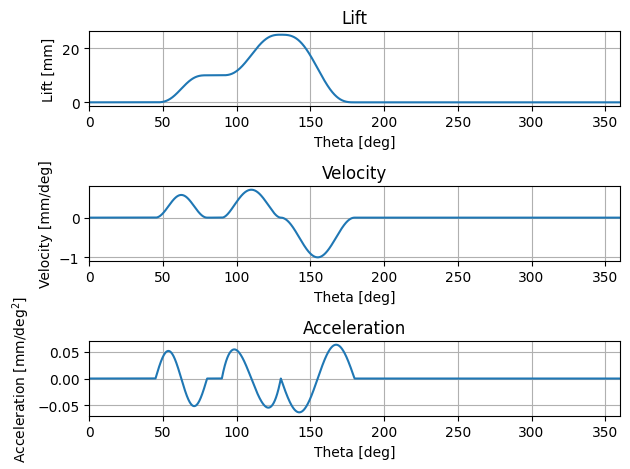

In [3]:
# Define a motion segment by giving values to the following variables
# Segment 1
startangle = 45
endangle = 80
startlift = 0
endlift = 10
motionlaw = 4 # 1: dwell, 2: minimal rms acceleration, 3: harmonic, 4: cycloid, 5: 5th degree poly, 6: 7th degree poly
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle, endangle, startlift, endlift, motionlaw, dtheta)

# Segment 2
startangle = 80
endangle = 90
startlift = 10
endlift = 10
motionlaw = 1

lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle, endangle, startlift, endlift, motionlaw, dtheta)

# Segment 3
startangle = 90
endangle = 130
startlift = 10
endlift = 25
motionlaw = 5

lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle, endangle, startlift, endlift, motionlaw, dtheta)

# Segment 4
startangle = 130
endangle = 180
startlift = 25
endlift = 0
motionlaw = 4

lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle, endangle, startlift, endlift, motionlaw, dtheta)

# Segment 5
startangle = 180
endangle = 360
startlift = 0
endlift = 0
motionlaw = 1

lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle, endangle, startlift, endlift, motionlaw, dtheta)

# Plot the motion law
plotMotionLaw(theta_deg, lift, vel_deg, acc_deg)

### Justification of motion law choices
- 45°-80° (+10 mm) → **Cycloidal**
  
  A cycloidal rise is used over 45–80° because it enforces zero acceleration at both ends and yields a smooth, low-jerk 10 mm lift under no external load.
- 90°-130° (+15 mm) → **5th degree polynomial**
  
  Occurs under increasing external load; this profile minimizes jerk and ensures a smooth transition into the following dwell. Since the motion right after this is in the opposite direction, the *velocity must be zero*.

  We don't know if a 7th degree polynomial is actually needed for this load. This is why we will try the design with a 5th degree polynomial and see if the vibrations are not too high.

  We opted for a polynomial and not for a cycloid, since the peak acceleration is smaller for a 5th degree polynomial. This means less forces.
- 130°-180° (-25 mm) → **Cycloidal**
  
  A single cycloidal return from 130-180° ensures zero acceleration at the start and end of the -25 mm stroke, producing a gentle, continuous release under the 350 N pull.
- Other intervals → Dwell

  No motion required, so constant lift is applied.

All motion laws respect the **general rule of thumb**: the motion law $x(\theta)$ must be continuous in the first and second derivative with respect to time of the cam, during the whole period $0 \leq \theta \leq 2\pi$.
- If we don't respect this rule, there will be unwanted forces and pressure areas on the cam. This leads to quicker wear of the cam.
- A harmonic motion law was not considered, because the actuation of the cam is not harmonic.

# 2. Design cam-follower geometry
The chosen cam-follower configuration for this assignment is one with a rotating
cam and a translating follower, equipped with a roll bearing.

The dimensioning of the cam-follower mechanism starts by finding the value of the pitch radius $R_0$ which ensures an acceptable value of the pressure angle along the whole cam motion. The function _Kloomok_Muffley_R0_  substitutes the Kloomok and Muffley nomogram presented in the lecture, allowing a more precise evaluation of $R_0$ and allowing a larger choice of motion laws. The function plots the maximum pressure angle as a function of $R_0$ for a specific segment (defined by the cam angle interval $\beta$, the start and end lift of the segment and the chosen type of motion law from the previous step). The plot can be used to find the maximum value of $R_0$ allowable for a specific dataset.

In [4]:
# @title
def Kloomok_Muffley_R0(beta, startlift, endlift, motionlaw):
    R0_vec = np.arange(0, 100, 0.1)
    alpha_max = np.zeros_like(R0_vec)

    L0 = startlift
    L1 = endlift
    beta = beta * np.pi / 180

    for i in range(len(R0_vec)):
        R0 = R0_vec[i]
        x = np.arange(0, 1, 0.01)

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonic
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # cycloid
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        alpha = np.arctan2(vel_ang, R0 + lift)
        alpha_max[i] = np.max(np.abs(alpha)) * 180 / np.pi

    plt.figure()
    plt.plot(R0_vec, alpha_max)
    plt.grid()
    plt.xlabel('$R_0$ (mm)')
    plt.ylabel(r'$\alpha_{max}$ (degree)')
    plt.xlim([0, 100])
    plt.show()

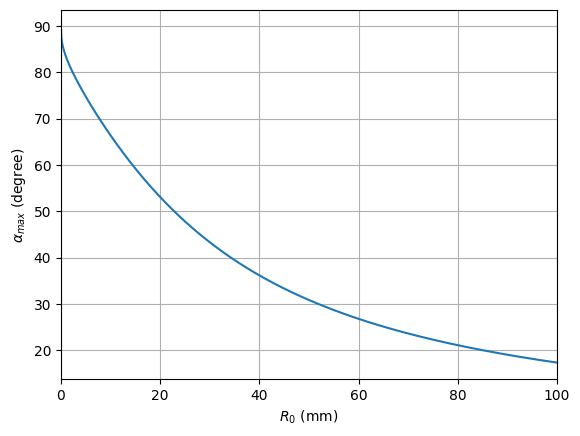

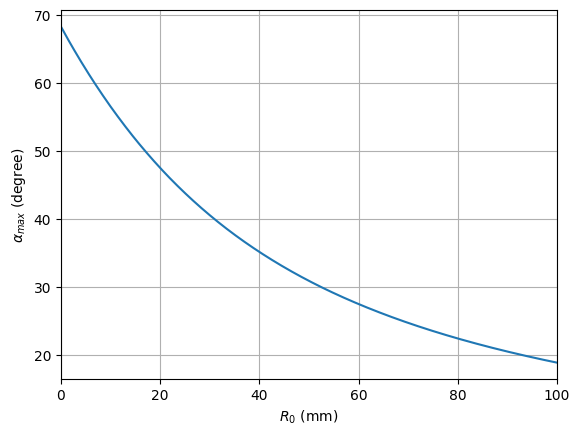

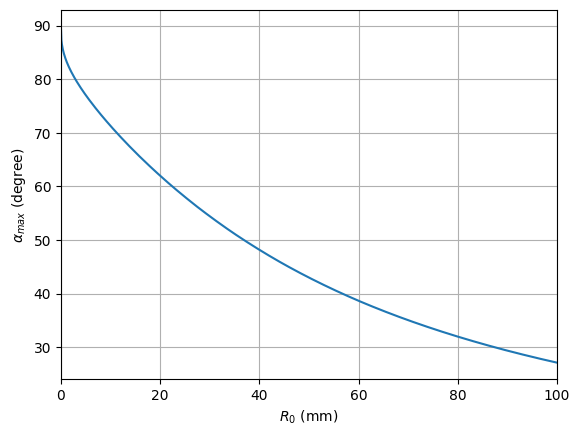

In [5]:
# Use the first Kloomok and Muffley figure to choose the pitch radius R0
# Insert the parameters value for a specific motion segment

# Segment 1
beta = 35
startlift = 0
endlift = 10
motionlaw = 4

Kloomok_Muffley_R0(beta, startlift, endlift, motionlaw)

# Segment 2: pressure angle = 0, because lift is constant

# Segment 3
beta = 40
startlift = 10
endlift = 25
motionlaw = 5

Kloomok_Muffley_R0(beta, startlift, endlift, motionlaw)

# Segment 4
beta = 50
startlift = 25
endlift = 0
motionlaw = 4

Kloomok_Muffley_R0(beta, startlift, endlift, motionlaw)

### Pitch radius explanation
**Chosen pitch radius $R_0 = 90 mm$**.

Based on rule of thumb: $|{\alpha}| < 30°$ (for a translating follower). The pressure angle indicates how much power is lost to friction and is therefore best kept as small as possible. Of course, this must also be practically feasible.

Once the pitch radius $R_0$ is chosen, the function _Kloomok_Muffley_follower_radius_ defined below allows to create the figure showing the minimum radius of curvature of the pitch curve $\rho_{min}$ as a function of the active cam angle $\beta$ (i.e. the cam angle interval) for a specific segment.
As a reminder, the radius of curvature of the pitch curve is defined as:

$\rho = \frac{((R_0+f(\theta))^2+(f'(\theta))^2)^{\frac{3}{2}}}{(R_0+f(\theta))^2+2(f'(\theta))^2-(R_0+f(\theta))\cdot f''(\theta)}$

Thus, the condition to prevent undercutting can be used to choose the follower radius.

In [6]:
# @title
def Kloomok_Muffley_follower_radius(R0, startlift, endlift, motionlaw, beta_segment):
    beta_vec = np.arange(1, 360, 0.1)
    rho_min = np.zeros_like(beta_vec)
    rho_min_segment = 0

    L0 = startlift
    L1 = endlift

    for i in range(len(beta_vec)):
        beta = beta_vec[i] * np.pi / 180
        theta = np.linspace(0, beta_vec[i], 100) * np.pi / 180
        x = theta / beta

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonic
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # cycloid
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        rho = ((R0 + lift)**2 + vel_ang**2)**(3/2) / ((R0 + lift)**2 + 2 * vel_ang**2 - (R0 + lift) * acc_ang)
        rho_min[i] = np.min(np.abs(rho))

        # We need to save the value of the interval bound
        if beta_segment <= beta_vec[i] and rho_min_segment == 0:
          rho_min_segment = rho_min[i]

    plt.figure()
    plt.plot(beta_vec, rho_min)
    plt.grid()
    plt.xlabel(r'$\beta$ (degrees)')
    plt.ylabel(r'$\rho_{min}$ (mm)')
    plt.xlim([0, 360])
    plt.show()

    return rho_min_segment

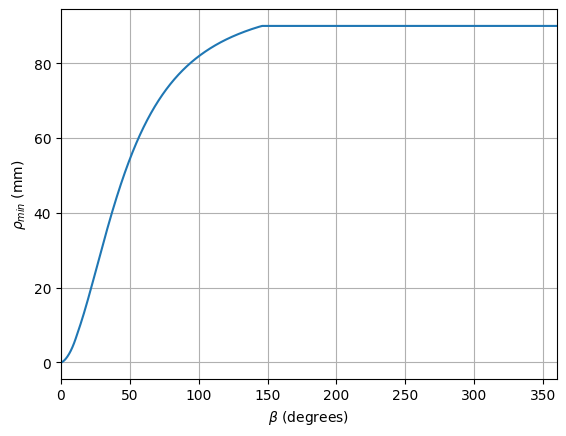

Rho_min of segment 1 = 37.46709107455703


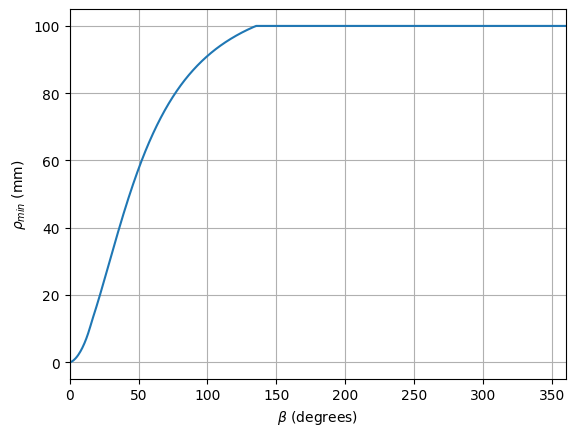

Rho_min of segment 3 = 45.33884161404455


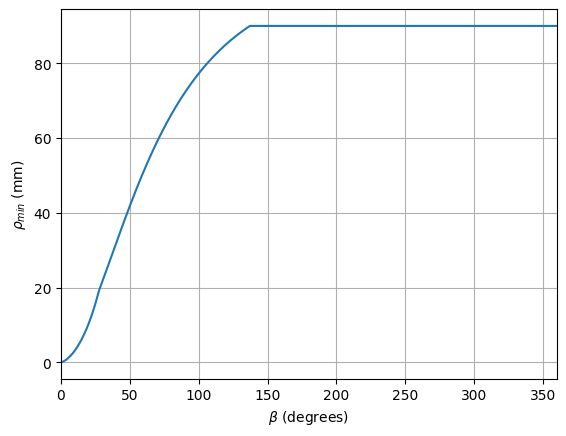

Rho_min of segment 4 = 41.79778538065936


In [7]:
# Use the second Kloomok and Muffley figure to choose the follower radius
# Insert the parameters value for a specific motion segment
R0 = 90  # pitch radius in mm (chosen in the previous step)

# Segment 1
beta = 35.0
startlift = 0
endlift = 10
motionlaw = 4

rho_min = Kloomok_Muffley_follower_radius(R0, startlift, endlift, motionlaw, beta) # Plot the figure
print("Rho_min of segment 1 =", rho_min)

# Segment 2: pressure angle = 0, because lift is constant

# Segment 3
beta = 40
startlift = 10
endlift = 25
motionlaw = 5

rho_min = Kloomok_Muffley_follower_radius(R0, startlift, endlift, motionlaw, beta)
print("Rho_min of segment 3 =", rho_min)

# Segment 4
beta = 50
startlift = 25
endlift = 0
motionlaw = 4

rho_min = Kloomok_Muffley_follower_radius(R0, startlift, endlift, motionlaw, beta)
print("Rho_min of segment 4 =", rho_min)

### Follower radius explanation
**Chosen follower radius $R_r = 35 mm$**

There mustn't be any undercutting, so $R_r < \rho_{min}$ at all times. we take a small margin for safety.

The choice of a cycloidal motion law for segment 1 results in a minimum radius of curvature $\rho_{\text{min}}$ that is comparable to that of segments 3 and 4.
If a 7th degree polynomial had been used for segment 1 instead, it would have led to a smaller $\rho_{\text{min}}$ for that segment. As a consequence, the follower radius R_r would also have had to be reduced in order to prevent undercutting.

A larger follower radius is preferred because it reduces the pressure angle, improves force transmission, minimizes friction and wear, and increases the contact area between the cam and follower. These benefits lead to a more efficient and durable mechanism.

Therefore, the use of a cycloidal motion law in segment 1 not only maintains smooth motion but also enables a larger allowable follower radius, which is advantageous for the overall performance of the cam-follower system.

Once the pitch radius and follower radius (and thus, base radius) are selected, the _calculatePressureAngle_ calculates the pressure angle along the whole cam motion to check if it stays within the desired limits (using the plot given by _plotPressureAngle_). Furthermore, the pressure angle curve can be optimised by introducing excentricity in the mechanism. Therefore, the pressure angle can be calculated as:

$\alpha = arctan(\frac{f'(\theta)-e}{\sqrt{R_0^2-e^2}+f(\theta)})$

Furthermore, the radius of curvature of the pitch and cam curves are calculated in the _calculateRadiusCurvature_ function. The figure given by _plotRadiusCurvature_ can be used to verify that there is no undercutting in the mechanism.

Finally, a sketch of the cam-follower mechanism is plotted using _plotCamContour_.

In [8]:
# @title
def calculatePressureAngle(vel,exc,base_radius,follower_radius,lift):
    pressure_angle = np.arctan((vel-exc)/(np.sqrt((base_radius+follower_radius)**2-exc**2)+lift))
    return pressure_angle

def plotPressureAngle(theta_deg,pressure_angle):
    plt.figure()
    plt.plot(theta_deg, pressure_angle*180/np.pi)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Pressure angle [deg]')
    plt.xlim([0,360])
    plt.grid()
    plt.title('Pressure angle')

def calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2) #Nortron, Kinematic and dynamics of Machinery eq. 8.31c
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2 # Nortron, Kinematic and dynamics of Machinery eq. 8.34, adapted for vertical follower instead of a horizontal one (--> + pi/2)
    dlambda = -1 + exc/((d+lift)**2 + exc**2) * vel # derivative of lambda with repect to theta
    ddlambda = exc/((d+lift)**2 + exc**2)*acc - 2*exc*(d+lift)*vel**2/((d+lift)**2 + exc**2)**2 # 2nd derivative of lambda with repect to theta

    g = np.sqrt((d+lift)**2 + exc**2)
    dg = vel*(d+lift)/np.sqrt((d+lift)**2 + exc**2) # derivative of g with repect to theta
    ddg = (vel**2  + acc*(d + lift))/np.sqrt((d + lift)**2 + exc**2) - (vel**2*(d + lift)**2)/((d + lift)**2 + exc**2)**(3/2) # 2nd derivative of g with repect to theta

    h = np.sin(lambda_)
    dh = np.cos(lambda_)*dlambda # derivative of h with repect to theta
    ddh = -np.sin(lambda_)*dlambda**2 + np.cos(lambda_)*ddlambda # 2nd derivative of h with repect to theta
    f = np.cos(lambda_)
    df = -np.sin(lambda_)*dlambda #derivative of f with repect to theta
    ddf = -np.cos(lambda_)*dlambda**2 - np.sin(lambda_)*ddlambda # 2nd derivative of f with repect to theta

    dx = df*g + f*dg #derivative of x with repect to theta
    ddx = ddf*g + 2*df*dg + f*ddg # 2nd derivative of x with repect to theta
    dy = dh*g + h*dg # derivative of y with repect to theta
    ddy = ddh*g + 2*dh*dg + h*ddg # 2nd derivative of y with repect to theta

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx) # general forumula for the radius of curvature
    roc_cam = roc_pitch - follower_radius

    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg,roc_pitch,roc_cam):
    inds = np.where(np.abs(np.diff(roc_pitch)/dtheta)<1e3)[0]
    maxi = max(10, max(roc_pitch[inds+1]))
    mini = min(-10, min(roc_pitch[inds+1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch, label='Pitch radius')
    plt.plot(theta_deg, roc_cam, label='Cam radius')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Radius of curvature [mm]')
    plt.xlim([0,360])
    plt.ylim([mini,maxi])
    plt.legend()
    plt.grid()
    plt.title('Radius of curvature')

def plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2
    xpitch = np.cos(lambda_)*np.sqrt((d+lift)**2 + exc**2)
    ypitch = np.sin(lambda_)*np.sqrt((d+lift)**2 + exc**2)

    xcam = xpitch + follower_radius*np.cos(-theta + pressure_angle + 3*np.pi/2)
    ycam = ypitch + follower_radius*np.sin(-theta + pressure_angle + 3*np.pi/2)

    pitch_curve = np.array([xpitch,ypitch])
    cam_curve = np.array([xcam,ycam])

    x_rolfol_center = exc  # x coordinate of the center of the roller of the follower
    y_rolfol_center = d + lift[0]  # y coordinate of the center of the roller of the follower
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center  # x coordinate of the contour of the roller
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center  # y coordinate of the contour of the roller

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius

    width_block_on_follower = base_radius / 2
    height_block_on_follower = base_radius / 2

    x_boreleft = np.array([exc - 5, exc - 1, exc - 1, exc - 5])
    x_boreright = np.array([exc + 5, exc + 1, exc + 1, exc + 5])
    y_bore = np.array([d + max(lift) + min_distance_center_roller_to_bore] * 2 + [d + max(lift) + min_distance_center_roller_to_bore + height_bore] * 2)
    length_follower = y_bore[-1] - ypitch[0] - follower_radius + 0.2

    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center + follower_radius, y_rolfol_center + follower_radius + length_follower])

    x_block_on_follower = np.array([-width_block_on_follower, width_block_on_follower, width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, height_block_on_follower, height_block_on_follower]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, base_radius]])  # line, indicating the reference (= cam position = 0 degrees)

    x_pressangle = np.array([x_rolfol_center + follower_radius * np.sin(pressure_angle[0]), x_rolfol_center - follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = np.array([y_rolfol_center - follower_radius * np.cos(pressure_angle[0]), y_rolfol_center + follower_radius * np.cos(pressure_angle[0])])

    plt.figure()
    plt.fill(cam_curve[0, ::int(1 / dtheta)], cam_curve[1, ::int(1 / dtheta)], 'b')
    plt.fill(x_rolfol[::int(1 / dtheta)], y_rolfol[::int(1 / dtheta)], 'g')
    plt.plot(pitch_curve[0, ::int(1 / dtheta)], pitch_curve[1, ::int(1 / dtheta)], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_pressangle, y_pressangle, 'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft, y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower, y_follower, 'r')
    plt.fill(x_block_on_follower, y_block_on_follower, 'g')

    xlimits = [min(pitch_curve[0, :]), max(pitch_curve[0, :])]
    ylimits = [min(pitch_curve[1, :]), d + max(lift) + follower_radius + length_follower + height_block_on_follower]

    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim(np.array(ylimits) * 1.05)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [mm]')

### Zero eccentricity

Pitch radius >= cam radius everywhere: True


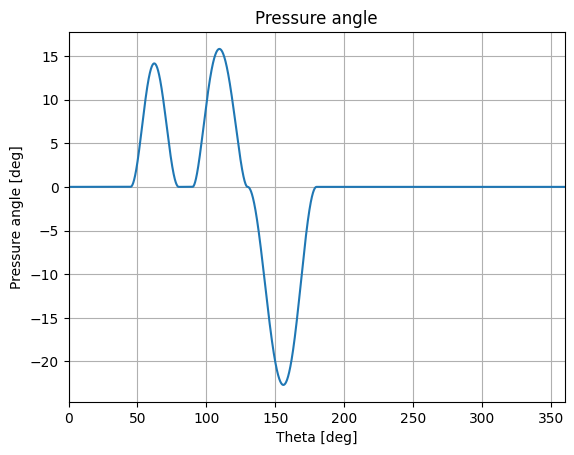

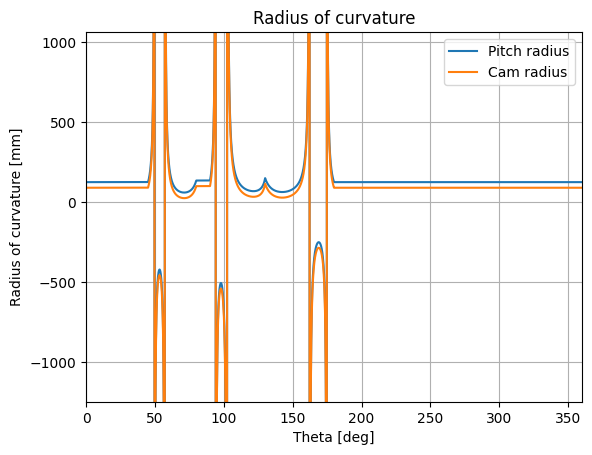

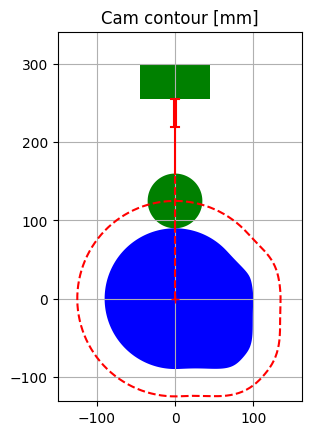

In [9]:
# Kinematics inputs
base_radius = 90 # base circle radius in mm
follower_radius = 35 # follower radius in mm
exc = 0 # excentricity in mm

# Calculate pressure angle
pressure_angle_zero_exc = calculatePressureAngle(vel, exc, base_radius, follower_radius, lift)

pressure_angle_positive_zero_exc = pressure_angle_zero_exc >= 0;

# Plot pressure angle
plotPressureAngle(theta_deg, pressure_angle_zero_exc)

# Calculate radius of curvature
roc_pitch, roc_cam = calculateRadiusCurvature(base_radius, follower_radius, exc, theta, lift, vel, acc)

# Verify that pitch radius is correct
roc_correct = roc_pitch >= roc_cam
print('Pitch radius >= cam radius everywhere:', all(roc_correct))

# Plot the radius of curvature
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam)

# Plot the cam contour
plotCamContour(base_radius, follower_radius, exc,theta, lift, pressure_angle_zero_exc, dtheta)

### Nonzero eccentricity

To reduce lateral forces on the follower, the effect of eccentricity was analyzed. Using numerical optimization (minimize_scalar), the eccentricity that minimizes the maximum absolute pressure angle over one cam cycle was determined. Within the interval [–30 mm, 30 mm], the optimal value was found to be –9.41 mm, resulting in a reduced maximum pressure angle of 19.3°, compared to 22° when no eccentricity is used.

This shows that the choice of eccentricity is not arbitrary but results in a clear improvement in force transmission, with lower friction and wear. The cam profile remains geometrically valid, as the radius of curvature stays above the 40 mm limit, avoiding undercutting.

In [10]:
from scipy.optimize import minimize_scalar
import numpy as np

def objective_eccentricity(exc, vel, base_radius, follower_radius, lift):
    """
    Doelfunctie: maximale absolute pressure angle voor een gegeven excentriciteit.
    """
    pressure_angle = calculatePressureAngle(vel, exc, base_radius, follower_radius, lift)
    max_abs_angle = np.max(np.abs(pressure_angle))
    return max_abs_angle  # What we want to minimize

# Optimalisation -30 en 30 mm
result = minimize_scalar(
    objective_eccentricity,
    bounds=(-30, 30),
    method='bounded',
    args=(vel, base_radius, follower_radius, lift)
)

# Results
optimal_e = result.x
min_max_pressure_angle = result.fun * 180 / np.pi

print(f"Optimal eccentricity: {optimal_e:.3f} mm")
print(f"Minimum max pressure angle: {min_max_pressure_angle:.2f} deg")

Optimal eccentricity: -9.410 mm
Minimum max pressure angle: 19.30 deg


Pitch radius >= cam radius everywhere: True


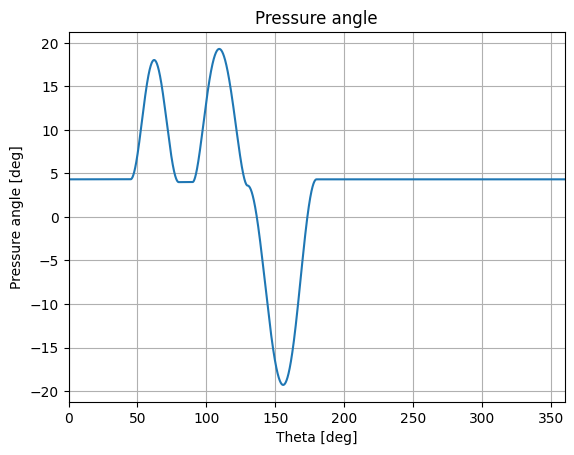

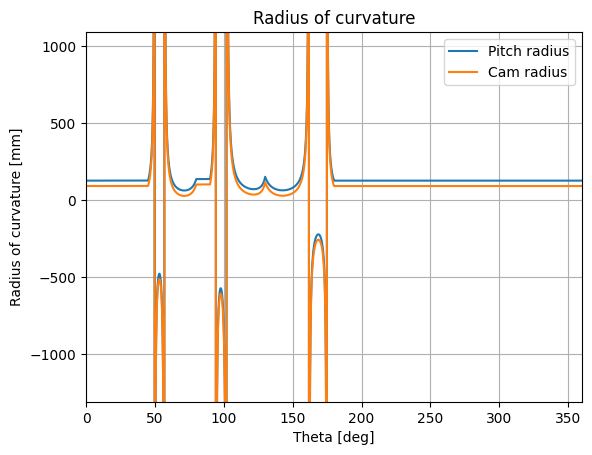

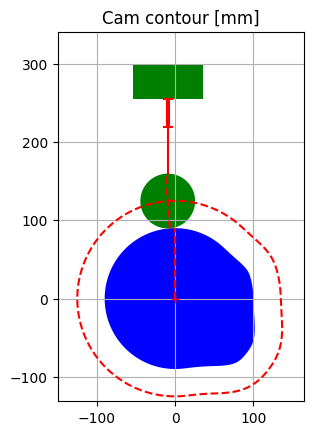

In [11]:
exc = optimal_e #-9.410 -> excentricity in mm

# Calculate pressure angle
pressure_angle_optimal_exc = calculatePressureAngle(vel, exc, base_radius, follower_radius, lift)

# Plot pressure angle
plotPressureAngle(theta_deg, pressure_angle_optimal_exc)

# Calculate radius of curvature
roc_pitch, roc_cam = calculateRadiusCurvature(base_radius, follower_radius, exc, theta, lift, vel, acc)

# Verify that pitch radius is correct
roc_correct = roc_pitch >= roc_cam
print('Pitch radius >= cam radius everywhere:', all(roc_correct))

# Plot the radius of curvature
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam)

# Plot the cam contour
plotCamContour(base_radius, follower_radius, exc,theta, lift, pressure_angle_optimal_exc, dtheta)

# 3. Veryfing rigid-body forces

## Generate external load

Each dataset contains the values of the functional load the mechanism must apply in different segments of the motion. The function _addLoadSegment_ can be used to define the external load along the whole cam motion. The latter is plotted using _plotExternalLoad_.

To note, compression forces (_druk-kracht_) are expressed with positive values, while pulling forces (_trek-kracht_) are expressed with negative values. Furthermore, for segments where no external load is specified, assume it to be zero.

In [12]:
# @title
def addLoadSegment(startangleload,endangleload,startload,endload,dtheta):
    assert startangleload - endangleload < 0, 'End angle should be bigger than start angle'
    start_index = int(startangleload/dtheta)
    end_index = int(endangleload/dtheta)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (endload - startload)/(endangleload - startangleload)*(theta_segment - startangleload) + startload

    return ext_load

def plotExternalLoad(theta_deg,ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [deg]')
    plt.ylabel('External load [N]')
    plt.xlim([0,360])
    plt.grid()
    plt.title('External load')

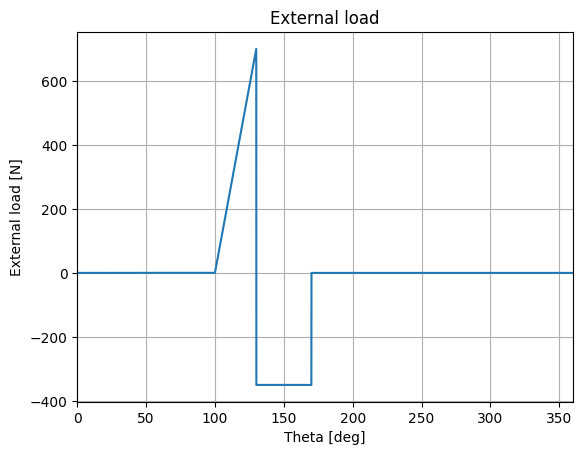

In [13]:
# Segment 1
startangleload = 0 # start angle of the load in degrees
endangleload = 100 # end angle of the load in degrees
startload = 0 # start load in N
endload = 0 # end load in N

# Add the segment to the external load
ext_load = addLoadSegment(startangleload,endangleload,startload,endload,dtheta)


# Segment 2
startangleload = 100 # start angle of the load in degrees
endangleload = 130 # end angle of the load in degrees
startload = 0 # start load in N
endload = 700 # end load in N

# Add the segment to the external load
ext_load = addLoadSegment(startangleload,endangleload,startload,endload,dtheta)


# Segment 3
startangleload = 130 # start angle of the load in degrees
endangleload = 170 # end angle of the load in degrees
startload = -350 # start load in N
endload = -350 # end load in N

# Add the segment to the external load
ext_load = addLoadSegment(startangleload,endangleload,startload,endload,dtheta)


# Segment 4
startangleload = 170 # start angle of the load in degrees
endangleload = 360 # end angle of the load in degrees
startload = 0 # start load in N
endload = 0 # end load in N

# Add the segment to the external load
ext_load = addLoadSegment(startangleload,endangleload,startload,endload,dtheta)

plotExternalLoad(theta_deg,ext_load)

## Spring design
The design of a spring is important to guarantee contact between the cam and the follower, i.e. to ensure that the follower tracks the correct motion. To ease the choice of the spring constant $k$ and the spring preload $F_{preload}$, the function _calculateForces_ calculates all the normal component of the forces applied on the system, namely:
- the functional forces (i.e. external load): $N_{load} = \frac{F_{load}}{cos(\alpha)},$

- the inertial force: $N_{inertial} = \frac{m\omega\frac{d^2S}{d\theta^2}}{cos(\alpha)}$

- the spring force: $N_{spring}= \frac{k\cdot S + F_{preload}}{cos(\alpha)}$

- the total normal force: $N_{tot} = N_{load} + N_{inertial} + N_{spring} = \frac{F_{load} + m\omega\frac{d^2S}{d\theta^2} + k\cdot S + F_{preload}}{cos(\alpha)}$

In [14]:
# @title
def calculateForce(rpm, lift, spring_constant, spring_preload, pressure_angle, ext_load, mass, acc):
    omega = rpm * 2 * np.pi / 60  # [rad/s]
    normalforce_spring = (lift * spring_constant + spring_preload) / np.cos(pressure_angle)
    normalforce_load = ext_load / np.cos(pressure_angle)
    normalforce_acc = mass * acc / 1000 * (omega ** 2) / np.cos(pressure_angle)
    normalforce_tot = normalforce_spring + normalforce_load + normalforce_acc
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot, normalforce_acc, normalforce_load, normalforce_spring, force_x, force_y

def calculateForceWithVibration(rpm, lift, spring_constant, spring_preload, pressure_angle, ext_load, mass, acc, normalforce_vib):
    omega = rpm * 2 * np.pi / 60  # [rad/s]
    normalforce_spring = (lift * spring_constant + spring_preload) / np.cos(pressure_angle)
    normalforce_load = ext_load / np.cos(pressure_angle)
    normalforce_acc = mass * acc / 1000 * (omega ** 2) / np.cos(pressure_angle)
    normalforce_tot = normalforce_spring + normalforce_load + normalforce_acc + normalforce_vib
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot, normalforce_acc, normalforce_load, normalforce_spring, force_x, force_y

def plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y,normalforce_vib=None):
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 3, 1)
    plt.plot(theta_deg,normalforce_tot)
    plt.plot(theta_deg,normalforce_acc,'--r')
    plt.plot(theta_deg,normalforce_load,':g')
    plt.plot(theta_deg,normalforce_spring,'-.m')

    if normalforce_vib is not None:
        plt.plot(theta_deg,normalforce_vib,':k')

    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.legend(['total','acceleration','ext. load','spring'] + ([] if normalforce_vib is None else ['vibration']))
    plt.grid()
    plt.title('Normal force')

    plt.subplot(1, 3, 2)
    plt.plot(theta_deg,force_x)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force x [N]')
    plt.xlim([0,360])
    plt.grid()
    plt.title('Force x')

    plt.subplot(1, 3, 3)
    plt.plot(theta_deg,force_y)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force y [N]')
    plt.xlim([0,360])
    plt.grid()
    plt.title('Force y')

def plotMultipleForces(theta_deg,normalforce_tot1,normalforce_acc1,normalforce_load1,normalforce_spring1,normalforce_tot2,normalforce_acc2,normalforce_load2,normalforce_spring2, normalforce_tot3,normalforce_acc3, normalforce_load3,normalforce_spring3, titles):
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 3, 1)
    plt.plot(theta_deg,normalforce_tot1)
    plt.plot(theta_deg,normalforce_acc1,'--r')
    plt.plot(theta_deg,normalforce_load1,':g')
    plt.plot(theta_deg,normalforce_spring1,'-.m')

    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.legend(['total','acceleration','ext. load','spring'] + ([]))
    plt.grid()
    plt.title(titles[0])

    plt.subplot(1, 3, 2)
    plt.plot(theta_deg,normalforce_tot2)
    plt.plot(theta_deg,normalforce_acc2,'--r')
    plt.plot(theta_deg,normalforce_load2,':g')
    plt.plot(theta_deg,normalforce_spring2,'-.m')

    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.legend(['total','acceleration','ext. load','spring'] + ([]))
    plt.grid()
    plt.title(titles[1])

    plt.subplot(1, 3, 3)
    plt.plot(theta_deg,normalforce_tot3)
    plt.plot(theta_deg,normalforce_acc3,'--r')
    plt.plot(theta_deg,normalforce_load3,':g')
    plt.plot(theta_deg,normalforce_spring3,'-.m')

    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.legend(['total','acceleration','ext. load','spring'] + ([]))
    plt.grid()
    plt.title(titles[2])

### No preload and no spring force

First we evaluate the normal force on the cam-follower interface without applying any spring preload or stiffness (i.e. $k = 0$, $F_0 = 0$). In this case, the total normal force is solely determined by the external load and the inertial effects due to follower acceleration.

The resulting force profile clearly shows a region where the total normal force drops well below zero. This indicates a loss of contact between the follower and the cam surface, which is physically unacceptable. A restoring force, typically provided by a spring, is therefore required to ensure continuous contact throughout the entire cam cycle.

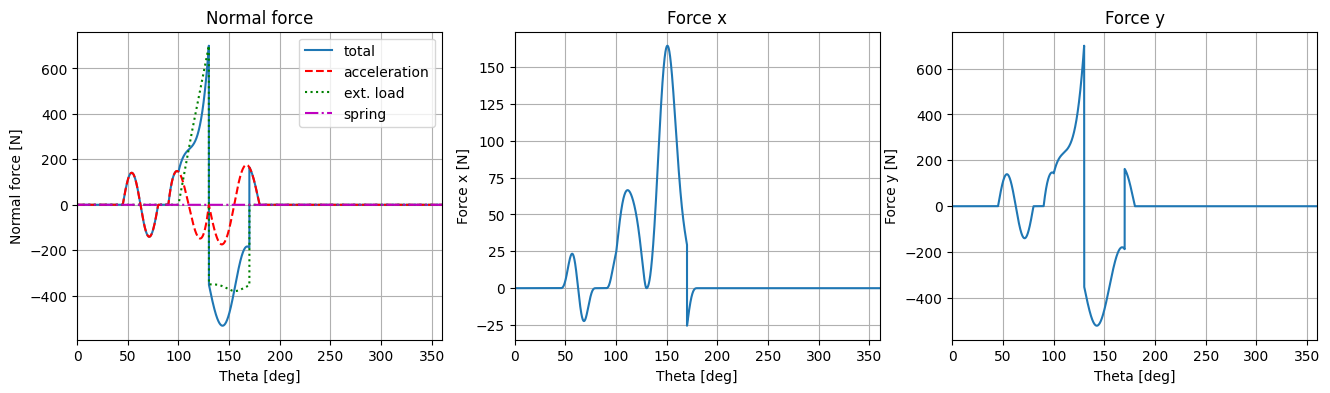

In [15]:
spring_constant = 0 # spring constant in N/mm
spring_preload = 0 # spring preload in N


# Calculate forces
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle_zero_exc,ext_load,mass,acc)

# Plot forces
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y)

### Preload only

To ensure that the follower remains in contact with the cam surface throughout the entire cycle, we determine the minimum required spring preload for a system with zero spring stiffness. This represents the worst-case scenario where the entire restoring force must come from the preload alone. The optimisation yields a preload value of 521 N, which is sufficient to keep the total normal force strictly positive at all times.

However, this high preload introduces a trade-off: although it prevents contact loss, it also leads to large force peaks during sections of the cycle where inertial and external loads are already high. These peaks may result in increased friction, wear, and overall stress on the cam-follower system. This highlights the need for a balanced spring design, combining preload and stiffness to maintain contact while limiting maximum forces.

In [16]:
from scipy.optimize import minimize_scalar

def find_minimum_spring_preload(rpm, lift, pressure_angle, ext_load, mass, acc):
    def constraint_func(F0):
        k = 0  # fixed spring stiffness
        normalforce_tot, *_ = calculateForce(rpm, lift, k, F0, pressure_angle, ext_load, mass, acc)
        return np.min(normalforce_tot)

    def objective(F0):
        if constraint_func(F0) <= 0:
            return 1e6 + abs(constraint_func(F0)) * 1e4
        return F0

    result = minimize_scalar(objective, bounds=(0, 1000), method='bounded')

    if result.success:
        F0_opt = result.x
        print(f"Minimum preload to maintain contact: {F0_opt:.2f} N")
    else:
        print("Optimization failed:", result.message)
        F0_opt = None

    return F0_opt

In [17]:
F0_min = find_minimum_spring_preload(
    rpm=rpm,
    lift=lift,             # array in mm
    pressure_angle=pressure_angle_optimal_exc, # array in rad
    ext_load=ext_load,             # scalar or array in N
    mass=mass,                     # scalar in kg
    acc=acc                # array in mm/s²
)

Minimum preload to maintain contact: 521.00 N


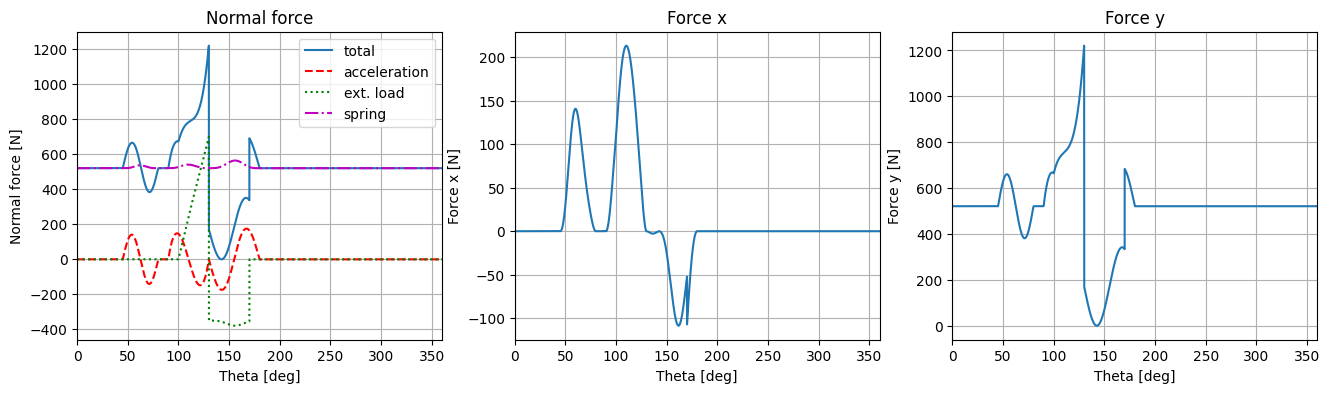

In [18]:
spring_constant = 0 # spring constant in N/mm
spring_preload = F0_min # spring preload in N

# Calculate forces
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle_zero_exc,ext_load,mass,acc)
# Plot forces
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y)

### Spring force only

In this case, we fix the spring preload at zero and determine the minimum required spring stiffness to ensure that the follower maintains continuous contact with the cam throughout the entire cycle. Using numerical optimisation, we find that a spring constant of 161.81 N/mm is needed to keep the total normal force strictly positive at all times.

This solution avoids the need for preload but comes at the cost of a relatively stiff spring. While this maintains contact effectively, it can still result in high force peaks, particularly in regions where inertial effects are already significant. In practice, a more balanced design — combining both preload and stiffness — may provide a better trade-off between contact reliability and force control.

In [19]:
from scipy.optimize import minimize_scalar
import numpy as np

def find_minimum_spring_constant(rpm, lift, pressure_angle, ext_load, mass, acc,
                                  k_bounds=(100, 200), tol=1e-2):
    """
    Zoekt de minimale veerconstante k (in N/mm) bij preload = 0 N,
    zodat de totale normale kracht altijd positief blijft.
    """

    def evaluate_min_normalforce(k):
        spring_preload = 0  # fixed preload
        normalforce_tot, *_ = calculateForce(
            rpm, lift, k, spring_preload, pressure_angle, ext_load, mass, acc
        )
        return np.min(normalforce_tot)

    def objective(k):
        min_force = evaluate_min_normalforce(k)
        if min_force <= 0:
            return 1e6 + abs(min_force) * 1e4
        return k

    result = minimize_scalar(
        objective,
        bounds=k_bounds,
        method='bounded',
        options={'xatol': tol}
    )

    if result.success:
        k_opt = result.x
        print(f"Minimum spring constant: {k_opt:.2f} N/mm (min force > 0)")
    else:
        print("Optimization failed:", result.message)
        k_opt = None

    return k_opt

In [20]:
k_min = find_minimum_spring_constant(
    rpm=rpm,
    lift=lift,
    pressure_angle=pressure_angle_optimal_exc,
    ext_load=ext_load,
    mass=mass,
    acc=acc,
    k_bounds=(100, 200)
)

Minimum spring constant: 161.81 N/mm (min force > 0)


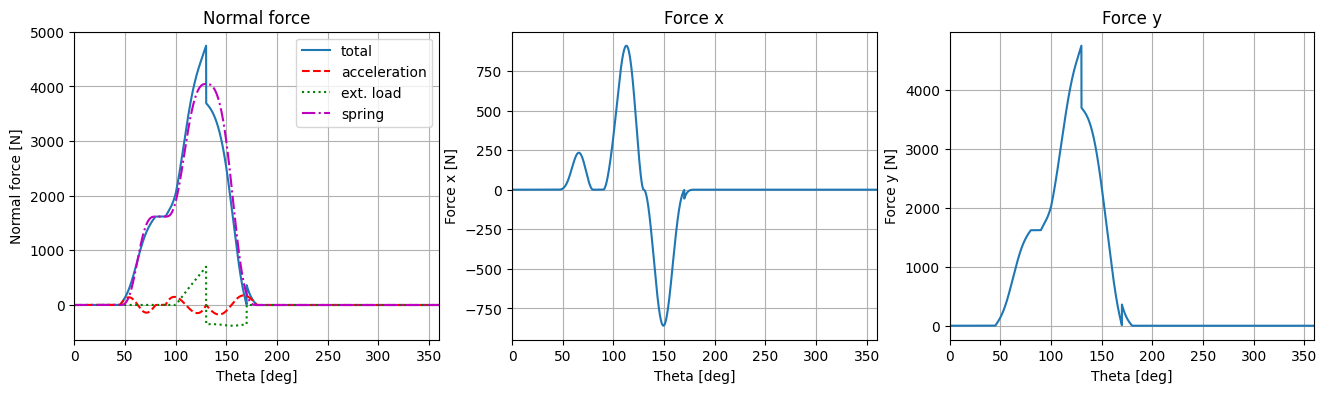

In [21]:
spring_constant = k_min # spring constant in N/mm
spring_preload = 0 # spring preload in N


# Calculate forces
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle_zero_exc,ext_load,mass,acc)
# Plot forces
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y)

### Optimal combination of spring preload and spring constant

To ensure continuous contact between the cam and follower, while keeping the peak contact force as low as possible, a grid search is performed to find the optimal combination of spring constant k and preload $F_0$. The search is limited to values of $k \in [0, 2]$ N/mm and $F_0 \in [470, 530]$ N, both with a resolution of 0.1.

The optimal combination is found at:
* 	$\mathbf{k = 0.00}$ N/mm
* 	$\mathbf{F_0 = 521.10}$ N

This configuration ensures that the total normal force remains strictly positive throughout the cam cycle, with a minimum value just above zero, and a maximum normal force of 1223.28 N.

To better understand the influence of spring stiffness, additional plots were generated for higher values of k (e.g. k = 1 N/mm). These show that adding stiffness does reduce the required preload slightly, but also increases peak force values in certain parts of the cycle. The case with k = 0 and carefully chosen preload therefore represents the most balanced solution within the tested range.

In [22]:
from tqdm import tqdm

def grid_search_optimal_spring(rpm, lift, pressure_angle, ext_load, mass, acc, theta_deg=None, vib_force=None):
    if vib_force is None:
        k_values = np.arange(0.0, 2.01, 0.2)
        F0_values = np.arange(300.0, 600.01, 1)
    else:
        k_values = np.arange(0.0, 20.01, 0.5)
        F0_values = np.arange(500.0, 1500.01, 10)

    best_k = None
    best_F0 = None
    best_max_force = np.inf

    for k in tqdm(k_values, desc="Searching k"):
        for F0 in F0_values:
            normalforce_tot, *_ = calculateForce(rpm, lift, k, F0, pressure_angle, ext_load, mass, acc) if vib_force is None else calculateForceWithVibration(rpm, lift, k, F0, pressure_angle, ext_load, mass, acc, vib_force)
            min_force = np.min(normalforce_tot)
            max_force = np.max(normalforce_tot)

            if min_force > 0 and max_force < best_max_force:
                best_max_force = max_force
                best_k = k
                best_F0 = F0

    if best_k is not None:
        print()
        print(f"Optimal k = {best_k:.2f} N/mm")
        print(f"Optimal F0 = {best_F0:.2f} N")
        print(f"Minimum normal force > 0, maximum = {best_max_force:.2f} N")
    else:
        print("No valid combination found that satisfies min(force) > 0.")

    return best_k, best_F0, best_max_force

In [23]:
best_k, best_F0, best_max_force = grid_search_optimal_spring(
    rpm=rpm,
    lift=lift,
    pressure_angle=pressure_angle_optimal_exc,
    ext_load=ext_load,
    mass=mass,
    acc=acc,
    theta_deg=theta_deg
)

Searching k: 100%|██████████| 11/11 [00:04<00:00,  2.50it/s]


Optimal k = 0.00 N/mm
Optimal F0 = 522.00 N
Minimum normal force > 0, maximum = 1224.18 N


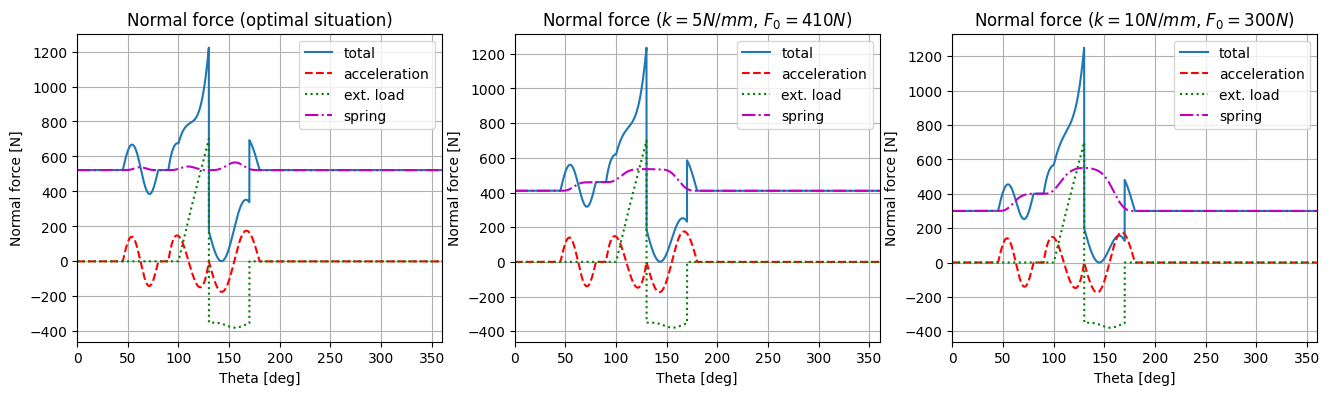

In [24]:
spring_constant1 = 0 # spring constant in N/mm
spring_preload1 = 522 # spring preload in N

spring_constant2 = 5 # spring constant in N/mm
spring_preload2 = 410 # spring preload in N

spring_constant3 = 10 # spring constant in N/mm
spring_preload3 = 300 # spring preload in N


# Calculate forces
[normalforce_tot1,normalforce_acc1,normalforce_load1,normalforce_spring1,force_x1,force_y1] = calculateForce(rpm,lift,spring_constant1,spring_preload1,pressure_angle_zero_exc,ext_load,mass,acc)
[normalforce_tot2,normalforce_acc2,normalforce_load2,normalforce_spring2,force_x2,force_y2] = calculateForce(rpm,lift,spring_constant2,spring_preload2,pressure_angle_zero_exc,ext_load,mass,acc)
[normalforce_tot3,normalforce_acc3,normalforce_load3,normalforce_spring3,force_x3,force_y3] = calculateForce(rpm,lift,spring_constant3,spring_preload3,pressure_angle_zero_exc,ext_load,mass,acc)

# Plot forces
plotMultipleForces(theta_deg,
          normalforce_tot1,normalforce_acc1,normalforce_load1,normalforce_spring1,
          normalforce_tot2,normalforce_acc2,normalforce_load2,normalforce_spring2,
          normalforce_tot3,normalforce_acc3,normalforce_load3,normalforce_spring3,
          ('Normal force (optimal situation)', 'Normal force ($k=5N/mm$, $F_0=410N$)', 'Normal force ($k=10N/mm$, $F_0=300N$)'))

### Doubling the angular velocity

When the cam rotates twice as fast, the contribution of the inertial forces to the normal forces quadruples. The figure points out that N is no longer positive at all
times. A higher spring constant or preload is required at this driving speed.

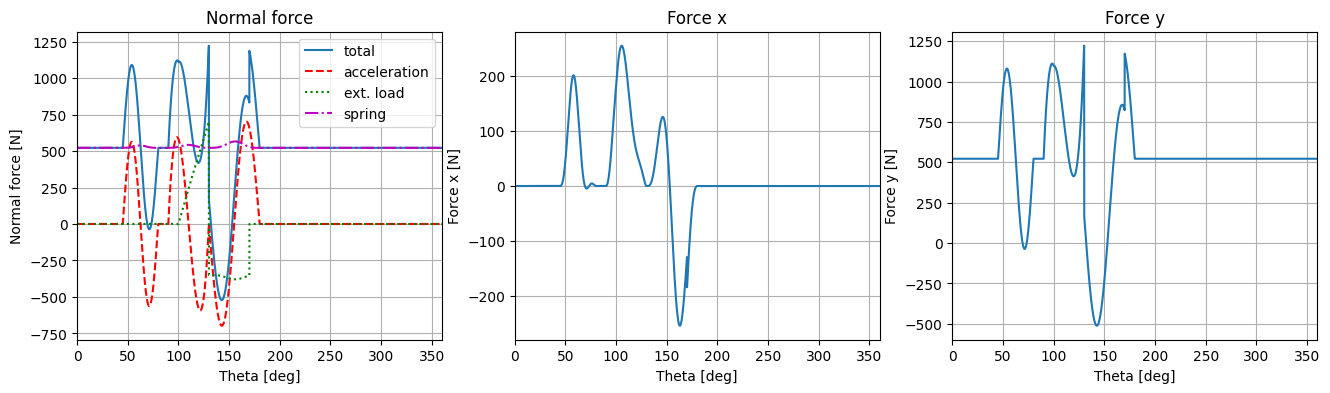

In [25]:
rpm_double = rpm * 2  # Doubled cam speed → now 120 RPM
spring_constant = 0 # spring constant in N/mm
spring_preload = 522 # spring preload in N

# Calculate forces
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y] = calculateForce(rpm_double,lift,spring_constant,spring_preload,pressure_angle_zero_exc,ext_load,mass,acc)
# Plot forces
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y)

## Power

To evaluate the energy transfer in the cam-follower system, we compute the instantaneous power transmitted at the contact point between cam and follower. This is given by:

\begin{equation}
P(\theta) = N(\theta) \cdot \omega \cdot \left[ e \cdot \cos(\alpha(\theta)) + \sin(\alpha(\theta)) \cdot \left( \sqrt{R_0^2 - e^2} + S(\theta) \right) \right]
\end{equation}

This formula accounts for the eccentricity $e$, pitch radius $R_0$, pressure angle $\alpha$, lift $S$, angular velocity $\omega$, and the normal force $N$. The derivation is based on the torque applied around the cam axis via the lever arm of the force vector projected onto the direction of rotation.

The instantaneous power transmitted at the cam-follower contact is computed for both cases: with and without eccentricity. As expected, the results are virtually identical. This outcome can be understood by considering the nature of the scalar product used to calculate power:

\begin{equation}
P(\theta) = \vec{F}_N(\theta) \cdot \vec{v}(\theta)
\end{equation}

In a cam-follower mechanism, the contact velocity vector $\vec{v}(\theta)$ is always tangent to the cam profile, and the normal force $\vec{F}_N(\theta)$ is, by definition, perpendicular to it. Introducing eccentricity changes the orientation of the force and the shape of the profile, but not the fact that these vectors remain orthogonal to the surface. Therefore, the projection of the force in the velocity direction — which defines power — remains effectively unchanged.

Mathematically, even though the lever arm and pressure angle vary, their combined effect in the power equation cancels out. This is consistent with the expressions found in literature and verified in the referenced reports. The difference between both cases is on the order of machine precision ($\sim 10^{-13}$), confirming that eccentricity influences the pressure angle and force distribution, but not the energy transfer over a full cycle.

As seen in the power plot, the instantaneous power becomes negative in some intervals. This corresponds to situations where the external or inertial forces push the cam instead of the cam driving the follower. In such moments, the cam-follower contact delivers energy back to the cam, effectively acting as a generator.

In [26]:
normalforce_tot_zero_exc = [] # normal force in N with zero excentricity
normalforce_tot_optimal_exc = [] # normal force in N with optimal excentricity

[normalforce_tot_zero_exc,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y] = calculateForce(rpm_double,lift,spring_constant,spring_preload,pressure_angle_zero_exc,ext_load,mass,acc)
[normalforce_tot_optimal_exc,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y] = calculateForce(rpm_double,lift,spring_constant,spring_preload,pressure_angle_optimal_exc,ext_load,mass,acc)

In [27]:
# Adjust the parameters for the calculation of the power error
S = lift * 1e-3  # lift in meter
R_0 = (base_radius + follower_radius) * 1e-3  # pitch radius in meter

# Without excentricity
zero_exc_m = zero_exc * 1e-3  # zero eccentricity in meter
power_without = normalforce_tot_zero_exc * omega * (zero_exc_m * np.cos(pressure_angle_zero_exc) + np.sin(pressure_angle_zero_exc) * (np.sqrt((R_0)**2 - zero_exc_m**2) + S))

# With excentricity
optimal_exc = optimal_e  # optimal eccentricity in mm
optimal_exc_m = optimal_exc * 1e-3  # eccentricity in meter
power_with = normalforce_tot_optimal_exc * omega * (optimal_exc_m * np.cos(pressure_angle_optimal_exc) + np.sin(pressure_angle_optimal_exc) * (np.sqrt((R_0)**2 - optimal_exc_m**2) + S))


# Difference in power
power_err = power_without - power_with

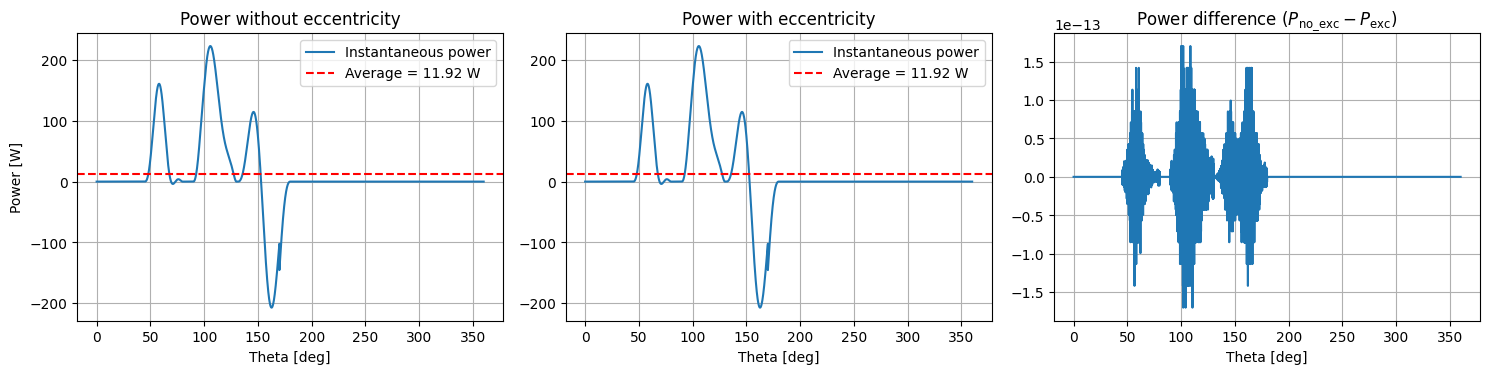

Average power = 11.92 W


In [28]:
# Calculate average power
average_power = np.mean(power_with)  # or power_without

plt.figure(figsize=(15, 4))

# Subplot 1: Without excentricity
plt.subplot(1, 3, 1)
plt.plot(theta_deg, power_without, label="Instantaneous power")
plt.axhline(y=average_power, color='r', linestyle='--', label=f"Average = {average_power:.2f} W")
plt.title("Power without eccentricity")
plt.xlabel("Theta [deg]")
plt.ylabel("Power [W]")
plt.grid()
plt.legend()

# Subplot 2: With excentricity
plt.subplot(1, 3, 2)
plt.plot(theta_deg, power_with, label="Instantaneous power")
plt.axhline(y=average_power, color='r', linestyle='--', label=f"Average = {average_power:.2f} W")
plt.title("Power with eccentricity")
plt.xlabel("Theta [deg]")
plt.grid()
plt.legend()

# Subplot 3: Difference
plt.subplot(1, 3, 3)
plt.plot(theta_deg, power_err)
plt.title(r"Power difference ($P_{\text{no\_exc}} - P_{\text{exc}}$)")
plt.xlabel("Theta [deg]")
plt.grid()

plt.tight_layout()
plt.show()

# Print the average value of the power
print(f"Average power = {average_power:.2f} W")

The average power over the full cycle is computed as:

\begin{equation}
P_{\text{avg}} = \frac{1}{T} \int_0^T P(t) \, dt
\end{equation}

In our system, the average power is strictly positive, indicating that the cam must deliver net energy to overcome the resistive and inertial forces of the follower. This is consistent with the expected behavior for a powered mechanism driven by a motor.

## Flywheel

The torque acting on the cam shaft is not constant throughout the cam cycle. Peaks occur when high acceleration or external loads must be overcome, while valleys appear during dwell phases or when the external forces push the cam. To prevent undesirable speed fluctuations due to these torque variations, a flywheel is introduced to store and release rotational energy as needed. This stabilizes the angular velocity of the system.

The torque delivered to the cam is computed as:
\begin{equation}
T(\theta) = N(\theta) \cdot \left[ e \cdot \cos(\alpha(\theta)) + \sin(\alpha(\theta)) \cdot \left( \sqrt{R_0^2 - e^2} + S(\theta) \right) \right]
\end{equation}

The average torque over one cycle is:
\begin{equation}
T_{\text{avg}} = \frac{P_{\text{avg}}}{\omega}
\end{equation}

From this, the torque surplus or deficit at each angle is defined as:
\begin{equation}
A(\theta) = \int_0^{\theta} \left( T(\theta) - T_{\text{avg}} \right) d\theta
\end{equation}

This function represents the cumulative energy deviation from the average torque and indicates whether the cam is accelerating or decelerating relative to the mean.

To limit the angular velocity variation to $\pm 5\%$, the required moment of inertia $I$  of the flywheel is determined based on the maximal energy deviation $ A_{\text{max}}$ using:

\begin{equation}
I = \frac{A_{\text{max}}}{K \cdot \omega_{\text{avg}}^2}
\end{equation}

Where:

*   $A_{\text{max}} = \max(A(\theta)) - \min(A(\theta))$
*   $\omega_{\text{avg}}$ is the nominal angular speed
*   $K = 0.1$ is the fluctuation coefficient for $\pm5\%$ speed variation

This equation ensures that the flywheel compensates for the energy surplus and deficit to keep the angular velocity within the desired tolerance.

Depending on design constraints, either a disc or a rim-type flywheel can be used:

*   A solid disc flywheel has inertia $( I = \frac{1}{2} m R^2)$
*   A rim flywheel concentrates mass at the perimeter, with ( $I \approx m R^2$), allowing for smaller mass


For a steel disc with known density and thickness, the flywheel radius can be computed accordingly:
\begin{equation}
R = \sqrt[4]{\frac{2I}{\pi \rho t}}
\end{equation}

This ensures the flywheel provides enough rotational inertia without overdimensioning the system.

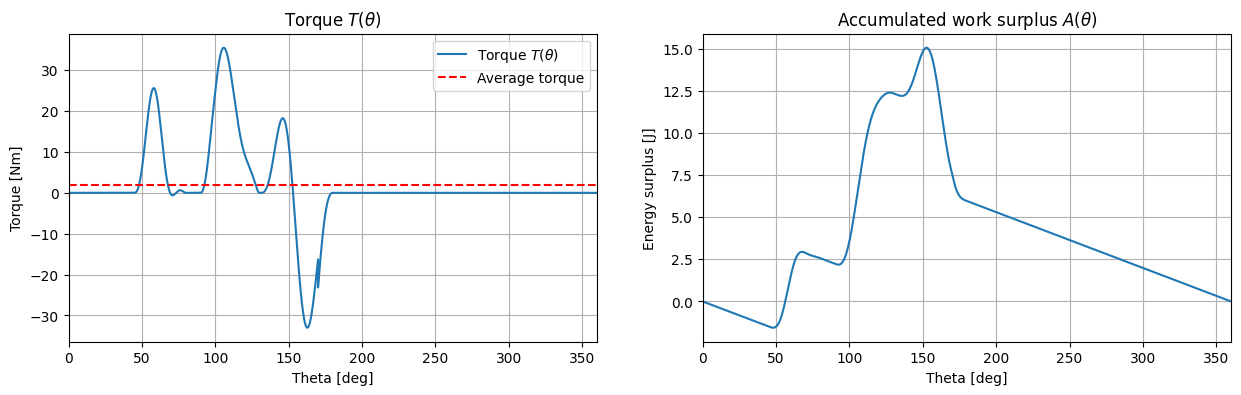

In [29]:
# Calculate torque [Nm]
torque = normalforce_tot_optimal_exc * (optimal_exc_m * np.cos(pressure_angle_optimal_exc) + np.sin(pressure_angle_optimal_exc) * (np.sqrt((R_0)**2 - optimal_exc_m**2) + S))

# Plot torque
plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.plot(theta_deg, torque, label=r'Torque $T(\theta)$')
plt.title(r'Torque $T(\theta)$')
plt.xlabel('Theta [deg]')
plt.xlim((0, 360))
plt.ylabel('Torque [Nm]')
plt.grid()

avg_torque = average_power / omega  # average torque [Nm]

# Horizontal line at average torque
plt.axhline(avg_torque, color='r', linestyle='--', label='Average torque')
plt.legend()

# Calculate A(θ): the accumulated energy deviation from the average torque
A = np.zeros_like(torque)
for i in range(1, len(torque)):
    A[i] = A[i-1] + (torque[i] - avg_torque) * (2 * np.pi / len(torque))  # Nm * rad = J

# Plot energy accumulation A(θ)
plt.subplot(1, 2, 2)
plt.plot(theta_deg, A)
plt.title(r'Accumulated work surplus $A(\theta)$')
plt.xlabel('Theta [deg]')
plt.xlim((0, 360))
plt.ylabel('Energy surplus [J]')
plt.grid()

- **Formulas used:**
  - Required moment of inertia: $I = \frac{A_{\text{max}}}{K \cdot \omega_{\text{avg}}^2}$
  - Disc flywheel radius: $R_{\text{disc}} = \sqrt[4]{\frac{2I}{\pi \rho t}}$
    
    Mass: $m_{\text{disc}} = \pi R_{\text{disc}}^2 t \rho$
  - Rim flywheel radius: $R_{\text{rim}} = \sqrt[3]{\frac{I}{2\pi \rho t b}}$
    
    Mass: $m_{\text{rim}} = 2\pi R_{\text{rim}} t b \rho$

- **Choices made:**
  - Material density: $\rho = 7850\,\mathrm{kg/m^3}$ (steel)
  - Thickness: $t = 0.03\,\mathrm{m}$
  - Rim width: $b = t$
  - Fluctuation coefficient: $K = 0.1$ (for $\pm5\%$ speed variation)

| | **Disc Flywheel** | **Rim Flywheel** |
|-|-|-|
| **Size**       | More compact (smaller radius) | Larger radius for the same inertia                 |
| **Mass**       | Heavier for the same inertia                        | Lower total mass (mass concentrated at the rim)    |
| **Distribution** | Mass is distributed throughout the volume           | Mass is concentrated at the perimeter              |
| **Efficiency** || Easier to achieve high inertia with less material, but may require more space |

In [30]:
# Calculate flywheel radius and mass for disc and rim flywheel

A_max = np.max(A) - np.min(A)  # [J], from energy deviation plot
omega_avg = omega              # [rad/s], nominal angular speed
K = 0.1                        # fluctuation coefficient for ±5% speed variation

# Required moment of inertia
I_required = A_max / (K * omega_avg**2)
print(f"Required moment of inertia I = {I_required:.4f} kg·m²")

# Flywheel material properties (steel)
rho = 7850    # density [kg/m³]
t = 0.03      # thickness [m], example value (adjust if you have a specific value)

# Disc flywheel: I = (1/2) * m * R^2, m = π * R^2 * t * ρ
# I = (1/2) * π * ρ * t * R^4  =>  R = [2I / (π ρ t)]^(1/4)
R_disc = (2 * I_required / (np.pi * rho * t))**0.25
m_disc = np.pi * R_disc**2 * t * rho

# Rim flywheel: I ≈ m * R^2, m = 2π * R * t * b * ρ (b = rim width, assume b = t)
# I = 2π * ρ * t * b * R^3  =>  R = [I / (2π ρ t b)]^(1/3)
b = t
R_rim = (I_required / (2 * np.pi * rho * t * b))**(1/3)
m_rim = 2 * np.pi * R_rim * t * b * rho

print(f"Disc flywheel radius R_disc = {R_disc:.3f} m ({R_disc*1000:.1f} mm)")
print(f"Disc flywheel mass   m_disc = {m_disc:.2f} kg")
print(f"Rim flywheel radius  R_rim  = {R_rim:.3f} m ({R_rim*1000:.1f} mm)")
print(f"Rim flywheel mass    m_rim  = {m_rim:.2f} kg")

Required moment of inertia I = 4.2072 kg·m²
Disc flywheel radius R_disc = 0.327 m (326.6 mm)
Disc flywheel mass   m_disc = 78.90 kg
Rim flywheel radius  R_rim  = 0.456 m (455.9 mm)
Rim flywheel mass    m_rim  = 20.24 kg


To quickly verify the result of the numerically integrated work surplus $A(\theta)$, we approximate the area between the torque curve and the average torque line using a triangle. This triangle spans from the point where the torque first drops below average to the point where it peaks above it. The base of the triangle is the angular range over which the torque exceeds the average, and the height is the maximum deviation from the average torque.

Since there are 3 peaks in our torque, we use 3 separate triangles to approximate. We use a function to find the base and top points, but we do specify the ranges in which these points are situated manually.

This approximation provides a fast and intuitive check of the flywheel energy calculation and is good engineering practice to validate numerical results.

Segment 45-75°: Area = 4.07 J, Peak at 58.1°, Torque = 25.62 Nm, Base at 48.0° and 67.7°
Segment 85-130°: Area = 10.25 J, Peak at 105.8°, Torque = 35.51 Nm, Base at 92.5° and 127.5°
Segment 130-180°: Area = 2.41 J, Peak at 145.9°, Torque = 18.26 Nm, Base at 135.7° and 152.6°


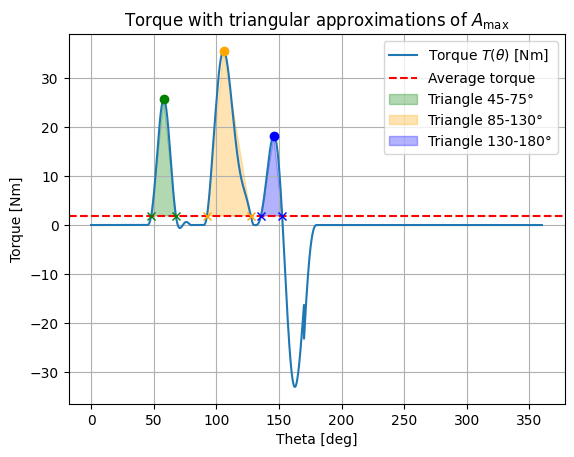

Total approximated A_max (sum of triangles) = 16.74 J
True A_max (numerical integration) = 16.61 J


In [31]:
def triangle_area_under_torque(theta_deg, torque, avg_torque, start_angle, end_angle, ax=None, color='green', alpha=0.3):
    # Find indices for the segment
    idx_start = np.searchsorted(theta_deg, start_angle)
    idx_end = np.searchsorted(theta_deg, end_angle)
    segment_theta = theta_deg[idx_start:idx_end]
    segment_torque = torque[idx_start:idx_end]

    # Find peak torque in the segment
    i_peak = np.argmax(segment_torque)
    theta_peak = segment_theta[i_peak]
    torque_peak = segment_torque[i_peak]

    # Find two base points: where |torque - avg_torque| is minimal in the segment
    abs_diff = np.abs(segment_torque - avg_torque)
    # To avoid picking the same minimum twice, mask out a small region around the first minimum
    i_base1 = np.argmin(abs_diff)
    # Mask out ±0.5° (or N points) around the first minimum
    mask = np.ones_like(abs_diff, dtype=bool)
    window = int(np.ceil(0.5 / (theta_deg[1] - theta_deg[0])))  # 0.5 degree window
    mask[max(0, i_base1 - window):min(len(abs_diff), i_base1 + window + 1)] = False
    abs_diff_masked = abs_diff.copy()
    abs_diff_masked[~mask] = np.inf
    i_base2 = np.argmin(abs_diff_masked)

    # Sort by angle to get left and right base
    i_base_sorted = np.sort([i_base1, i_base2])
    theta_base1 = segment_theta[i_base_sorted[0]]
    theta_base2 = segment_theta[i_base_sorted[1]]
    torque_base1 = segment_torque[i_base_sorted[0]]
    torque_base2 = segment_torque[i_base_sorted[1]]

    # Calculate triangle area using these base points and the peak
    base_rad = np.deg2rad(theta_base2 - theta_base1)
    height = abs(torque_peak - avg_torque)
    area = 0.5 * base_rad * height

    # Plot the triangle if ax is given
    if ax is not None:
        ax.fill(
            [theta_base1, theta_peak, theta_base2],
            [avg_torque, torque_peak, avg_torque],
            color=color, alpha=alpha, label=f'Triangle {start_angle}-{end_angle}°'
        )
        ax.plot([theta_base1, theta_base2], [torque_base1, torque_base2], 'x', color=color)

    return area, theta_peak, torque_peak, (theta_base1, theta_base2)

# Segments with peaks
segments = [(45, 75), (85, 130), (130, 180)]
areas = []

# Plot the torque and triangles
fig, ax = plt.subplots()
ax.plot(theta_deg, torque, label='Torque $T(\\theta)$ [Nm]')
ax.axhline(avg_torque, color='red', linestyle='--', label='Average torque')

colors = ['green', 'orange', 'blue']
for i, (start, end) in enumerate(segments):
    area, theta_peak, torque_peak, (theta_base1, theta_base2) = triangle_area_under_torque(
        theta_deg, torque, avg_torque, start, end, ax=ax, color=colors[i % len(colors)]
    )
    areas.append(area)
    ax.plot(theta_peak, torque_peak, 'o', color=colors[i % len(colors)])
    print(f"Segment {start}-{end}°: Area = {area:.2f} J, Peak at {theta_peak:.1f}°, Torque = {torque_peak:.2f} Nm, Base at {theta_base1:.1f}° and {theta_base2:.1f}°")

A_approx_total = sum(areas)
ax.set_xlabel('Theta [deg]')
ax.set_ylabel('Torque [Nm]')
ax.set_title('Torque with triangular approximations of $A_{\\max}$')
ax.legend()
ax.grid()
plt.show()

print(f"Total approximated A_max (sum of triangles) = {A_approx_total:.2f} J")

# Print exact results
A_exact = np.max(A) - np.min(A)
print(f"True A_max (numerical integration) = {A_exact:.2f} J")

The triangular approximation yields a value of 16.73 J, while the true energy surplus calculated via numerical integration is 16.60 J. This confirms that the triangle method was a correct approximation the required flywheel energy.

To properly dimension the motor for a cam-driven system, both the **average and peak torque requirements must be considered**.
- During nominal operation, the motor must continuously deliver the average power required by the cam-follower interaction. This is calculated from the average of the instantaneous power curve and serves as a basis for thermal sizing of the motor.
- Startup behavior poses an additional challenge. At startup, the motor must accelerate both the cam and flywheel from rest, overcoming the moment of inertia. This requires significantly more torque than during steady-state operation. The required startup torque can be estimated by summing the static load torque and the inertial torque due to angular acceleration.
- To reduce startup load, the system can be designed so that the cam is initially disengaged, allowing the motor to bring the flywheel up to speed before engaging the cam. This staged approach prevents overdimensioning the motor.
- The flywheel, in turn, helps smooth out torque fluctuations during operation. - Proper motor sizing ensures not only reliable startup but also protects against excessive peak loads and enables downstream design choices, including bearing strength, follower dynamics, and fatigue life estimation.

# 4. Dynamics of a flexible follower

## Accuracy conditions of single rise analysis

**What are the requirements that have to be satisfied for a valid single rise analysis?**

- Transient response of the other rise/falls have died out. This means a **sufficiently long dwell before and after** the rise/fall in question.
- The start conditions (lift and velocity) are known.
- The vibrations caused by earlier cycles and motion segments are neglected.

**What condition has to be satisfied for the approximate single-rise analysis? Can this condition be quantified with a formula?**

When using the approximate solution, the assumption is made that the **homogeneous solution has died out** at $\tau = 1$.

The slides mention the following equation to obtain an maximum error rate of at most 10%:
\begin{equation}
  \zeta \lambda > 0.75 \rightarrow \lambda_\text{min} = 8.33
\end{equation}
We will use this value of $\lambda$ to select our follower structural spring contant $k_f$.

**Find the most critical rise/fall to determine the follower stiffness. By selecting the most critical rise/fall, the calculated follower stiffness will be suitable for every rise/fall. Indicate clearly what makes a rise/fall the most critical one.**

The “most critical” segment is the one with the **shortest rise/fall duration**, since it has the highest cam forcing frequency $\omega_{\rm cam}$. This is the same as the segment with the smallest $\Delta\theta$, as the actuation is constant.

In our application, this is the **first rise** (+10 mm from 45° until 80°).

**Calculate the equivalent follower stiﬀness $k_f$ for the chosen critical
rise/fall and make sure that the previous condition is met. Although the equivalent stiﬀness of the follower is given in most applications, it is one of the design parameters in this assignment.**

We will ignore $k_s$ in this calculation (in our case, this doesn't even matter as $k_s = 0$).

\begin{align}
&\zeta \lambda > 0.75 \\
\Leftrightarrow \quad &\zeta \frac{t_1}{t_n} > 0.75 \\
\Leftrightarrow \quad &\zeta \frac{t_1 \sqrt{k_f}}{2 \pi \sqrt{m}} > 0.75 \\
\Leftrightarrow \quad &k_f = \frac{(1.5\pi)^2 m}{(t_1 \zeta)^2} = 6.09 \times 10^6~\text{N/m}
\end{align}

where:
- $m = 21~\text{kg}$ (equivalent mass)
- $t_1 = 0.0972~\text{s}$ (duration of shortest rise)
- $\zeta = 0.09$ (damping ratio)

In [32]:
# Constants from previous calculations
m = 21 # equivalent mass of the follower in kg
zeta = 0.09 # damping ratio of the follower

k_s = spring_constant * 1e3 # spring constant in N/m

# Calculate spring constant of follower using the given formula:
# k_f > ((1.5 * pi)^2 * m) / (t1 * zeta)^2

T_cycle = 1 / (rpm / 60) # cycle time in s
dtheta_shortest = 80 - 45 # shortest rise/fall

t1 = T_cycle * dtheta_shortest / 360  # duration of the shortest rise/fall in seconds

# Use the formula from the image
k_f = ((1.5 * np.pi) ** 2 * m) / (t1 * zeta) ** 2

# Calculate it differently and check results (for comparison)
# Use the formula from the image:
# k_f = m * (2 * np.pi * lam / t1) ** 2
lam = 0.75 / zeta # from the condition of the cam
k_f2 = m * (2 * np.pi * lam / t1) ** 2
omega_n = 2 * np.pi * lam / t1
omega_cam = 2 * np.pi / t1

# Verify that the ratio is respected
print("Spring constant of follower: k_f =", k_f)
print("Sprint constant of follower (other calculation): k_f2 =", k_f2)
print("Verification of k_f pick:", omega_n / omega_cam, "≥", lam)

# Verify that the homogenous part of the response died out at tau=1
# print("Homogenous response at tau=1:", np.exp(-zeta * 2 * np.pi * lam))

Spring constant of follower: k_f = 6090955.858958005
Sprint constant of follower (other calculation): k_f2 = 6090955.858958004
Verification of k_f pick: 8.333333333333334 ≥ 8.333333333333334


## Numerical results

### Single rise numerical simulation

**Choose a rise/fall directly followed by a long 'dwell'.**

Last fall (-25 mm) from 130° until 180°.

* **Motion equation for the cam-follower system:**
  The motion equation includes the model's parameters ($c$, $k_f$, and $m$), the function of the imposed displacement $u(t)$, and the follower’s response $y(t)$:
  $$
  m \cdot \ddot{y}(t) + c \cdot \dot{y}(t) + k_f \cdot y(t) = k_f \cdot u(t)
  $$
* **Dimensionless transformation:**
  This differential equation can be made dimensionless by transforming the parameters into dimensionless forms, as shown below:
  $$
  \left\{
    \begin{array}{l}
      \tau = \frac{t}{t_1} \\
      \theta(\tau) = \frac{u(t)}{h} \\
      \gamma(\tau) = \frac{y(t)}{h} \\
      h = 25 \text{mm           (the displacement)}
    \end{array}
  \right.
  $$
* **Dimensionless equation of motion:**
  $$
  \ddot{\gamma}(\tau) + 2\zeta (2\pi\lambda) \dot{\gamma}(\tau) + (2\pi\lambda)^2 \gamma(\tau) = (2\pi\lambda)^2 \theta(\tau)
  $$

Amplitude of the response at tau=1: 2.806E-04


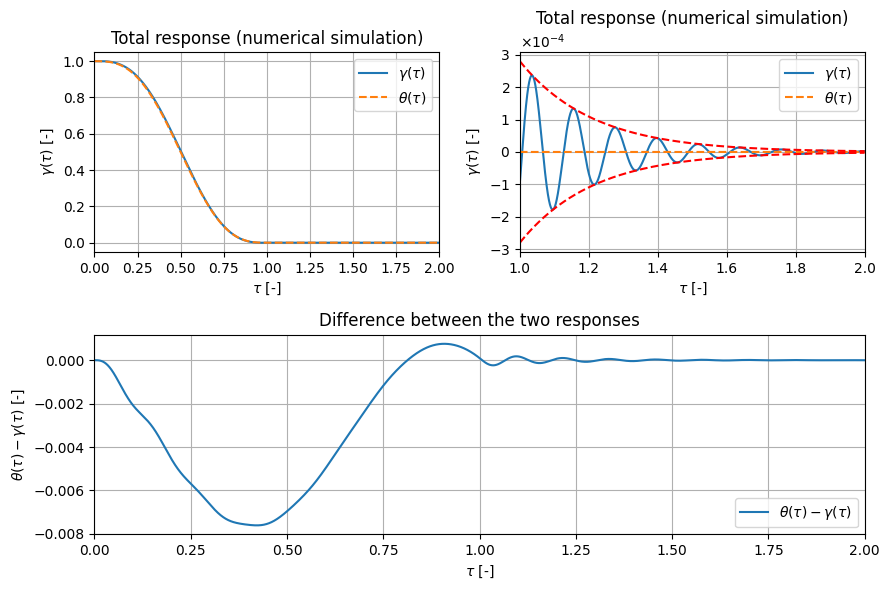

In [33]:
# Runs a simulation of the cam follower system
def runSimulation(startangle, endangle, startlift, endlift, theta, lift, lambda_, zeta):
    h = endlift - startlift

    # Cycloidal lift from 0 -> 1
    mask = (np.rad2deg(theta) >= startangle) & (np.rad2deg(theta) <= endangle)

    if h >= 0:
        lift_theta1 = (lift[mask] * 1e-3 - startlift) / h # dimensionless lift
        lift_theta2 = np.ones_like(lift_theta1) # Depends if lift is rise/fall
    else:
        lift_theta1 = np.ones_like(lift[mask]) - (startlift - lift[mask] * 1e-3) / -h
        lift_theta2 = np.zeros_like(lift_theta1) # Depends if lift is rise/fall
    lift_theta = np.concatenate([lift_theta1, lift_theta2])

    tau1 = np.linspace(0, 1, len(lift_theta1), endpoint=False) # 0 to 1 (forced)
    tau2 = np.linspace(1, 2, len(lift_theta2), endpoint=False) # 1 to 2 (free response)
    tau = np.concatenate([tau1, tau2])

    # Simulate response
    lift_theta0 = 0 if h > 0 else 1 # initial dimensionless replacement
    lift_theta_dot0 = 0 # intial dimensionless velocity

    # Create the system response function
    numerator = (2 * np.pi * lambda_) ** 2
    denominator = [1, 2 * zeta * (2 * np.pi * lambda_), (2 * np.pi * lambda_) ** 2]

    [A, B, C, D] = scipy.signal.tf2ss(numerator, denominator)
    X0 = [1/C[0,1]*lift_theta_dot0, 1/C[0,1]*lift_theta0]
    system = scipy.signal.lti(A, B, C, D)

    t_out, gamma, _ = scipy.signal.lsim(system, lift_theta, tau, X0)

    return tau, lift_theta, gamma, t_out

# Plot the response
def plotResponse(lift_theta, gamma, t_out, A=None, zeta=None, omega_d=None):
    plt.figure(figsize=(9, 6))

    plt.subplot(2, 2, 1)
    plt.plot(t_out, gamma, label=r'$\gamma(\tau)$')
    plt.plot(t_out, lift_theta, '--', label=r'$\theta(\tau)$')
    plt.xlabel(r'$\tau$ [-]')
    plt.xlim((0, 2))
    plt.ylabel(r'$\gamma(\tau)$ [-]')
    plt.title(r'Total response (numerical simulation)')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    mask = (t_out >= 1) & (t_out <= 2)
    plt.plot(t_out[mask], gamma[mask], label=r'$\gamma(\tau)$')
    plt.plot(t_out[mask], lift_theta[mask], '--', label=r'$\theta(\tau)$')
    if A is not None and zeta is not None and omega_d is not None:
        tau_env = t_out[mask]
        env = A * np.exp(-zeta * 2 * np.pi * lam * (tau_env - 1))
        plt.plot(tau_env, env, 'r--')
        plt.plot(tau_env, -env, 'r--')
    plt.xlabel(r'$\tau$ [-]')
    plt.xlim((1, 2))
    plt.ylabel(r'$\gamma(\tau)$ [-]')
    plt.title(r'Total response (numerical simulation)')
    plt.legend()
    plt.grid(True)

    ax = plt.gca()
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))  # Forces scientific notation for numbers < 1e-3 or > 1e3
    ax.yaxis.set_major_formatter(formatter)

    # Plot the difference between the two responses (theta - gamma)
    plt.subplot(2, 2, (3, 4))
    plt.plot(t_out, lift_theta - gamma, label=r'$\theta(\tau) - \gamma(\tau)$')
    plt.xlabel(r'$\tau$ [-]')
    plt.xlim((0, 2))
    plt.ylabel(r'$\theta(\tau) - \gamma(\tau)$ [-]')
    plt.title(r'Difference between the two responses')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Segment parameters of inspected segment
startangle = 130
endangle = 180
startlift = 0.025
endlift = 0.0 # end lift in m of the chosen motion segment

t1 = T_cycle * (endangle - startangle) / 360

tau, lift_theta, gamma, t_out = runSimulation(startangle, endangle, startlift, endlift, theta, lift, lam, zeta)

# Calculate the amplitude of the response at tau=1
# Find the index closest to tau = 1
idx_tau1 = np.argmin(np.abs(t_out - 1))

# x0 and x0_dot for the free response (start values at tau=1)
x0 = gamma[idx_tau1]

dtau = t_out[1] - t_out[0]
x0_dot = (gamma[idx_tau1 + 1] - gamma[idx_tau1 - 1]) / (2 * dtau)

# Analytical estimate of gamma(tau) for tau >= 1
lambda_d = lam * np.sqrt(1 - zeta**2)
omega_d = 2 * np.pi * lambda_d
A1 = np.sqrt((x0 * omega_d)**2 + (x0_dot + zeta * 2 * np.pi * x0 * lam)**2) / omega_d

print(f"Amplitude of the response at tau=1: {A1:.3E}",)

# Plot the response
plotResponse(lift_theta, gamma, t_out, A=A1, zeta=zeta, omega_d=omega_d)

The results above show the numerical response of the flexible follower system to a single rise, as well as the analytical calculation of the **amplitude envelope** at $\tau = 1$. The envelope $A_1$ is computed using the formula:

$$
A_1 = \sqrt{\frac{(x_0 \cdot (2\pi\lambda_d))^2 + (\dot{x}_0 + \zeta \cdot (2\pi\lambda) \cdot x_0)^2}{(2\pi\lambda_d)^2}}
$$

where:
- $\lambda_d = \lambda \cdot \sqrt{1 - \zeta^2}$ is the damped frequency ratio,
- $x_0 = \gamma(1)$ is the displacement at $\tau = 1$ relative to the input,
- $\dot{x}_0 = \dot{\gamma}(1)$ is the velocity at $\tau = 1$.

This analytical envelope provides a direct measure of the amplitude of the free (homogeneous) vibration that remains after the forced motion ends. By overlaying this envelope on the simulated response, we verify that the numerical solution behaves as expected: **the free response decays exponentially with the correct amplitude and rate**, confirming both the correctness of the simulation and the validity of the theoretical model.

Additionally, the **transfer function** of the system is given by:

$$
\frac{\Gamma(s)}{\Theta(s)} = \frac{(2\pi\lambda)^2}{s^2 + 2\zeta(2\pi\lambda)s + (2\pi\lambda)^2}
$$

This transfer function was used to simulate the system's response and to analytically derive the envelope. The close agreement between the simulated and analytical results demonstrates that the model accurately captures the dynamics of the flexible follower, and that the envelope calculation serves as a reliable verification tool for the transient response.

### Multi-rise analysis

The figure and accompanying text highlight a key limitation of single rise analysis: it only applies when a **single rise or fall is followed by a sufficiently long dwell**, allowing all vibrations to die out. In practical cam-follower systems, however, multiple rises and falls often occur in succession, and the system does not always return to rest between events.

The multi-rise analysis addresses this by **redefining the dimensionless time $\tau$ and frequency ratio $\tilde{\lambda}$** to account for the entire cam period and the natural period of the follower.
- $\tau$: dimensionless time: $\tau= t/T$.
- $\tilde{\lambda} = T/t_n$: amount of periods of undampened eigenfrequencies during one cam rotation

This approach captures the cumulative effect of vibrations from previous cycles and motion segments.
- As shown in the simulation, even after many cycles, small residual vibrations from the previous fall can influence the response at the start of the next rise.
- These vibrations are not present in the single-rise case, but become visible when zooming in on the multi-rise response.
- Since there is a long dwell at the start and end, the vibrations of the previous cycle died out when the next cycle is started.
- During a cycle, however, the vibrations do have an effect. This is especially noticable in the last fall, that immediately succeeds a small rise. The vibrations of that rise are still visible!

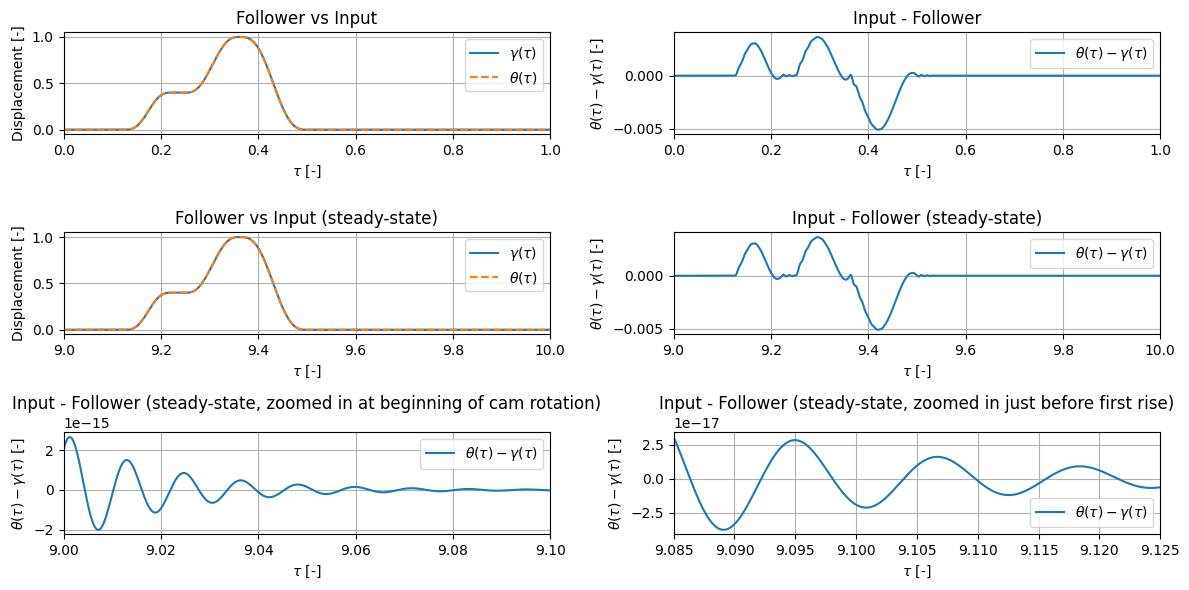

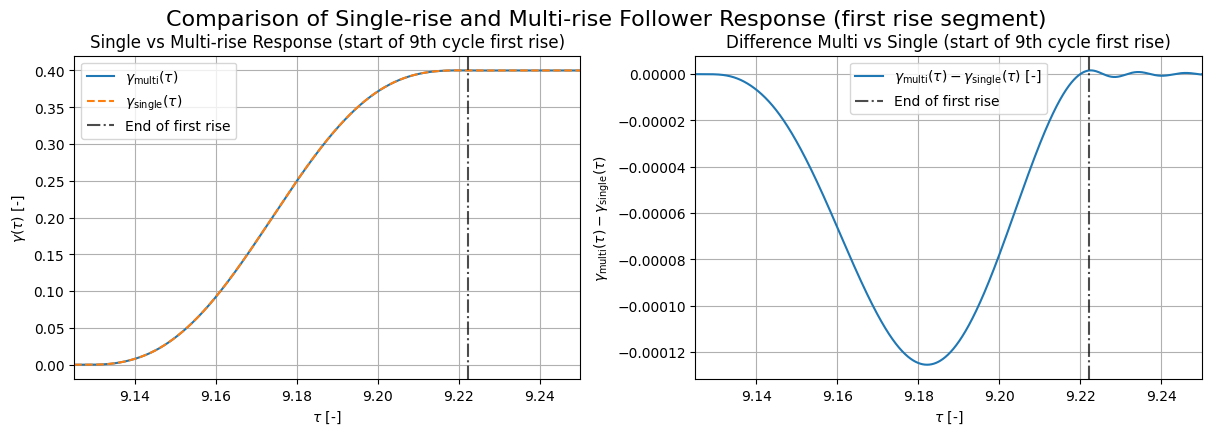

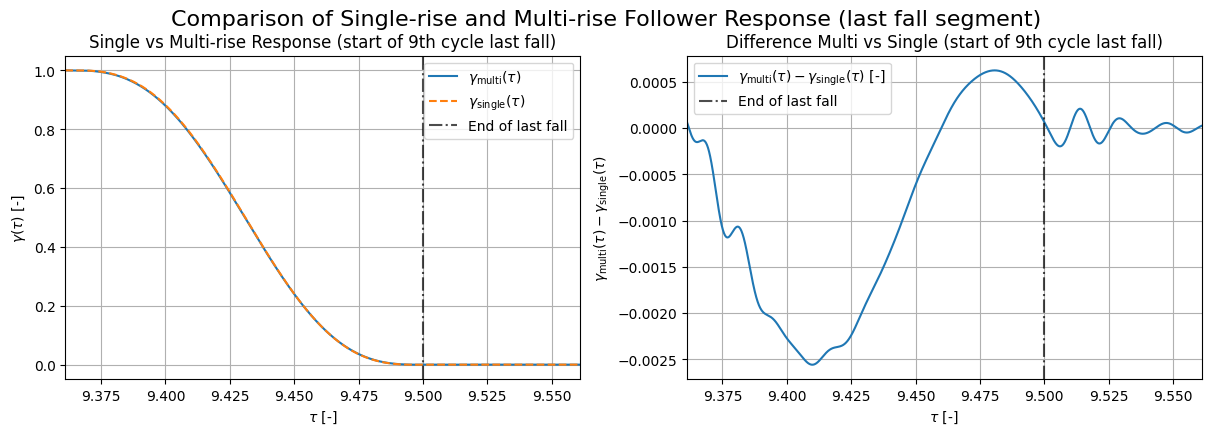

In [34]:
# Run multi-rise simulation
def runMultiRiseSimulation(theta, lift, lam, zeta, n_cycles=20):
    # Make the input dimensionless: theta_dimless = lift / h_max, where h_max is the max total lift
    h_max = np.max(lift) - np.min(lift)
    lift_theta = (lift - np.min(lift)) / h_max  # dimensionless lift in [0, 1]

    # Repeat the input for n_cycles
    tau_full = np.linspace(0, n_cycles, n_cycles * len(lift_theta), endpoint=False)
    lift_theta_full = np.tile(lift_theta, n_cycles)

    # System definition (same as single-rise)
    numerator = (2 * np.pi * lam) ** 2
    denominator = [1, 2 * zeta * (2 * np.pi * lam), (2 * np.pi * lam) ** 2]
    [A, B, C, D] = scipy.signal.tf2ss(numerator, denominator)
    X0 = [0, 0]  # Start with zero initial conditions
    system = scipy.signal.lti(A, B, C, D)

    # Simulate the response
    t_out, gamma, _ = scipy.signal.lsim(system, lift_theta_full, tau_full, X0)

    # Extract the last cycle (steady-state)
    # idx_last = -len(lift_theta)
    # tau_last = tau_full[idx_last:]
    # gamma_last = gamma[idx_last:]
    # lift_last = lift_theta_full[idx_last:]

    # return tau_last, lift_last, gamma_last, t_out[idx_last:]

    return tau_full, lift_theta_full, gamma, t_out

# Calculate lam_multi = T / t_n, where T is the cam period and t_n is the natural period of the follower
omega_n = np.sqrt((k_f + k_s) / m)  # natural frequency [rad/s]
t_n = 2 * np.pi / omega_n           # natural period [s]
lam_multi = T_cycle / t_n                 # multi-rise lambda

n_cycles = 10
tau, lift_theta, gamma, t_out = runMultiRiseSimulation(theta, lift, lam_multi, zeta, n_cycles=n_cycles)

# Plot the last cycle (steady-state)
# Number of points per cycle
points_per_cycle = len(tau) // n_cycles

# Masks for first and last cycle
mask_first = np.arange(0, points_per_cycle)
mask_last = np.arange(len(tau) - points_per_cycle, len(tau))

plt.figure(figsize=(12, 6))

# Row 1, Left: gamma and lift_theta (dimensionless)
plt.subplot(3, 2, 1)
plt.plot(tau[mask_first], gamma[mask_first], label=r'$\gamma(\tau)$')
plt.plot(tau[mask_first], lift_theta[mask_first], '--', label=r'$\theta(\tau)$')
plt.xlabel(r'$\tau$ [-]')
plt.xlim((0, 1))
plt.ylabel(r'Displacement [-]')
plt.title(r'Follower vs Input')
plt.legend()
plt.grid()

# Row 1, Right: difference (dimensionless)
plt.subplot(3, 2, 2)
plt.plot(tau[mask_first], lift_theta[mask_first] - gamma[mask_first], label=r'$\theta(\tau) - \gamma(\tau)$')
# plt.semilogy(tau[mask_first], np.abs(lift_theta[mask_first] - gamma[mask_first]), label=r'$\theta(\tau) - \gamma(\tau)$')
plt.xlabel(r'$\tau$ [-]')
plt.xlim((0, 1))
plt.ylabel(r'$\theta(\tau) - \gamma(\tau)$ [-]')
plt.title(r'Input - Follower')
plt.legend()
plt.grid()

# Row 2, Left: gamma and lift_theta (dimensionless, last cycle)
plt.subplot(3, 2, 3)
plt.plot(tau[mask_last], gamma[mask_last], label=r'$\gamma(\tau)$')
plt.plot(tau[mask_last], lift_theta[mask_last], '--', label=r'$\theta(\tau)$')
plt.xlabel(r'$\tau$ [-]')
plt.xlim((n_cycles-1, n_cycles))
plt.ylabel(r'Displacement [-]')
plt.title(r'Follower vs Input (steady-state)')
plt.legend()
plt.grid()

# Row 2, Right: difference (dimensionless, last cycle)
plt.subplot(3, 2, 4)
plt.plot(tau[mask_last], lift_theta[mask_last] - gamma[mask_last], label=r'$\theta(\tau) - \gamma(\tau)$')
# plt.semilogy(tau[mask_last], np.abs(lift_theta[mask_last] - gamma[mask_last]), label=r'$\theta(\tau) - \gamma(\tau)$')
plt.xlabel(r'$\tau$ [-]')
plt.xlim((n_cycles-1, n_cycles))
plt.ylabel(r'$\theta(\tau) - \gamma(\tau)$ [-]')
plt.title(r'Input - Follower (steady-state)')
plt.legend()
plt.grid()

# Zoom in on the beginning of the last cycle
zoom = 0.1
mask_zoom = np.arange(len(tau) - points_per_cycle, len(tau) - int(points_per_cycle * (1 - zoom)))

plt.subplot(3, 2, 5)
plt.plot(tau[mask_zoom], lift_theta[mask_zoom] - gamma[mask_zoom], label=r'$\theta(\tau) - \gamma(\tau)$')
plt.xlabel(r'$\tau$ [-]')
plt.xlim((n_cycles-1, n_cycles - 1 + zoom))
plt.ylabel(r'$\theta(\tau) - \gamma(\tau)$ [-]')
plt.title(r'Input - Follower (steady-state, zoomed in at beginning of cam rotation)')
plt.legend()
plt.grid()

# Zoom in on the part just before the first rise (at 45°) of the last cycle
zoom = 0.04
rise_perc = 45 / 360
mask_zoom_2 = np.arange(len(tau) - int(points_per_cycle * (1 - rise_perc + zoom)), len(tau) - int(points_per_cycle * (1 - rise_perc)))

plt.subplot(3, 2, 6)
plt.plot(tau[mask_zoom_2], lift_theta[mask_zoom_2] - gamma[mask_zoom_2], label=r'$\theta(\tau) - \gamma(\tau)$')
plt.xlabel(r'$\tau$ [-]')
plt.xlim((n_cycles - 1 + rise_perc - zoom, n_cycles - 1 + rise_perc))
plt.ylabel(r'$\theta(\tau) - \gamma(\tau)$ [-]')
plt.title(r'Input - Follower (steady-state, zoomed in just before first rise)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

def compare_single_multi_rise(
    tau, gamma, n_cycles,
    startangle, endangle, startlift, endlift,
    rise_perc, zoom,
    theta, lift, lam, zeta,
    segment_label="fall"
):
    cycle_idx = n_cycles - 1
    tau_start = cycle_idx + rise_perc

    # Find indices for the zoomed region
    tau_zoom_start = tau_start
    tau_zoom_segment_end = tau_start + (endangle - startangle) / 360  # end of the rise segment
    tau_zoom_end = tau_start + zoom
    mask_compare = np.where((tau >= tau_zoom_start) & (tau <= tau_zoom_end))[0]

    # Single-rise simulation (n_cycles=1)
    tau_single, lift_theta_single, gamma_single, t_out_single = runSimulation(
        startangle, endangle, startlift, endlift, theta, lift, lam, zeta
    )

    # Adjust tau for single-rise to match the multi-rise cycle
    rise_length_perc = (endangle - startangle) / 360  # length of the rise in percentage of the cycle
    tau_single_shifted = tau_single * rise_length_perc + tau_start

    # Scale down the single-rise response to match the multi-rise response
    gamma_single_shifted = gamma_single * abs(endlift - startlift) / 0.025  # scale to match the max lift of the multi-rise response

    # Find indices for the same region in single-rise
    mask_single = np.where((tau_single_shifted >= tau_zoom_start) & (tau_single_shifted <= tau_zoom_end))[0]

    # Make sure previous invocations of this function won't add extra plots
    plt.close('all')
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    axes = axes.flatten()

    # Left: Overlap single and multi-rise
    # plt.subplot(1, 2, 1)
    axes[0].plot(tau[mask_compare], gamma[mask_compare], label=r'$\gamma_\text{multi}(\tau)$')
    axes[0].plot(tau_single_shifted[mask_single], gamma_single_shifted[mask_single], '--', label=r'$\gamma_\text{single}(\tau)$')
    axes[0].axvline(tau_zoom_segment_end, color='k', linestyle='-.', alpha=0.7, label=f'End of {segment_label}')
    axes[0].set_xlabel(r'$\tau$ [-]')
    axes[0].set_xlim((tau_zoom_start, tau_zoom_end))
    axes[0].set_ylabel(r'$\gamma(\tau)$ [-]')
    axes[0].set_title(f'Single vs Multi-rise Response (start of 9th cycle {segment_label})')
    axes[0].legend()
    axes[0].grid()

    # Right: Difference
    # plt.subplot(1, 2, 2)
    # Interpolate single-rise to multi-rise tau for fair comparison
    gamma_single_interp = np.interp(
        tau[mask_compare], tau_single_shifted[mask_single], gamma_single_shifted[mask_single]
    )
    axes[1].plot(
        tau[mask_compare], gamma[mask_compare] - gamma_single_interp,
        label=rf'$\gamma_\text{{multi}}(\tau) - \gamma_\text{{single}}(\tau)$ [-]'
    )
    axes[1].axvline(tau_zoom_segment_end, color='k', linestyle='-.', alpha=0.7, label=f'End of {segment_label}')
    axes[1].set_xlabel(r'$\tau$ [-]')
    axes[1].set_xlim((tau_zoom_start, tau_zoom_end))
    axes[1].set_ylabel(r'$\gamma_\text{multi}(\tau) - \gamma_\text{single}(\tau)$')
    axes[1].set_title(f'Difference Multi vs Single (start of 9th cycle {segment_label})')
    axes[1].legend()
    axes[1].grid()

    fig.suptitle(f"Comparison of Single-rise and Multi-rise Follower Response ({segment_label} segment)", fontsize=16, y=1.05)
    # fig.tight_layout()
    plt.show()

# First rise
compare_single_multi_rise(
    tau=tau,
    gamma=gamma,
    n_cycles=n_cycles,
    startangle=45,
    endangle=80,
    startlift=0,
    endlift=0.01,
    rise_perc=45/360,
    zoom=0.125,
    theta=theta,
    lift=lift,
    lam=lam,
    zeta=zeta,
    segment_label="first rise"
)

# Last fall
compare_single_multi_rise(
    tau=tau,
    gamma=gamma,
    n_cycles=n_cycles,
    startangle=130,
    endangle=180,
    startlift=0.025,
    endlift=0.0,
    rise_perc=130/360,
    zoom=0.2,
    theta=theta,
    lift=lift,
    lam=lam,
    zeta=zeta,
    segment_label="last fall"
)

### Additional force due to vibrations

The forces on the rigid body were analyzed by considering the follower as infinitely stiff. In this section, the stiffness of the follower, $k_f$, is taken into account. This results in an additional spring force:

\begin{equation}
N = \frac{F_\text{func} + F_{v0} + k_v S + k_f \left(\theta(t) - \gamma(t)\right) \cdot h + m \cdot \omega^2 \frac{d^2S}{d\theta^2}}{\cos(\alpha)}
\end{equation}

The figure shows the impact of this extra spring force on the normal force.

Previously, a spring constant and preload were designed to ensure that there is always contact between the cam and the follower. This is achieved when the total normal force remains positive throughout the entire cycle.

As can be seen in the figure below, this condition is no longer satisfied. The return spring must therefore be recalculated to prevent any loss of contact.

The output shows the new results (an approximation as we don't want this to take too long) and a plot showing that the new spring constant and preload satisfy the condition again.

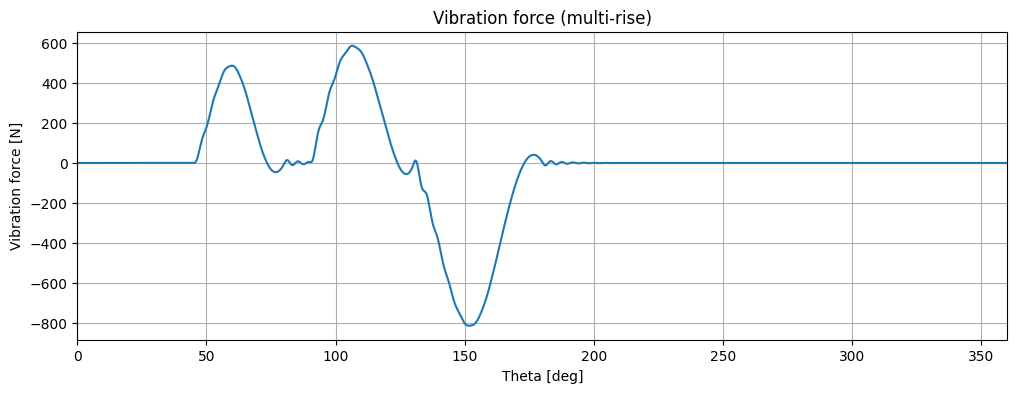

Searching k: 100%|██████████| 41/41 [00:05<00:00,  7.48it/s]



Optimal k = 11.50 N/mm
Optimal F0 = 1020.00 N
Minimum normal force > 0, maximum = 2095.58 N


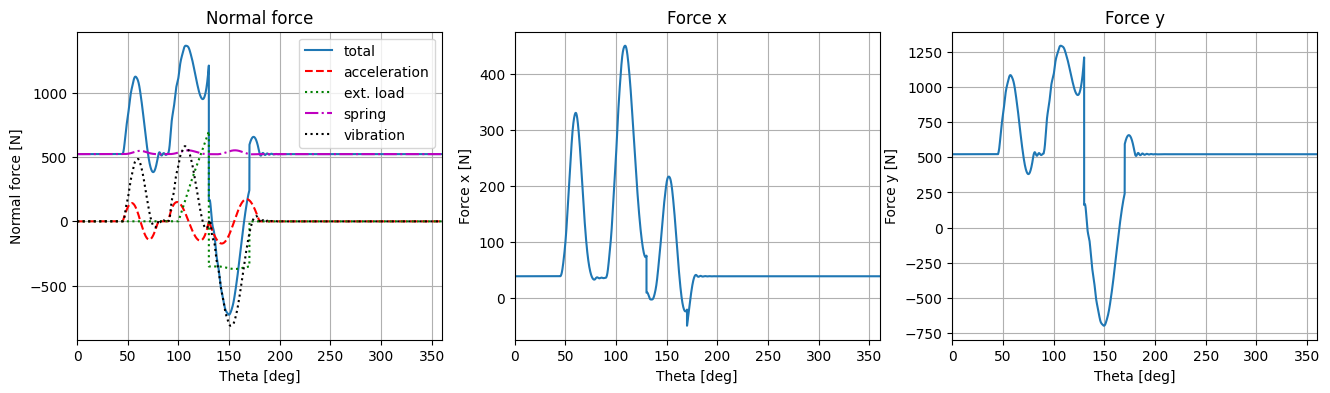

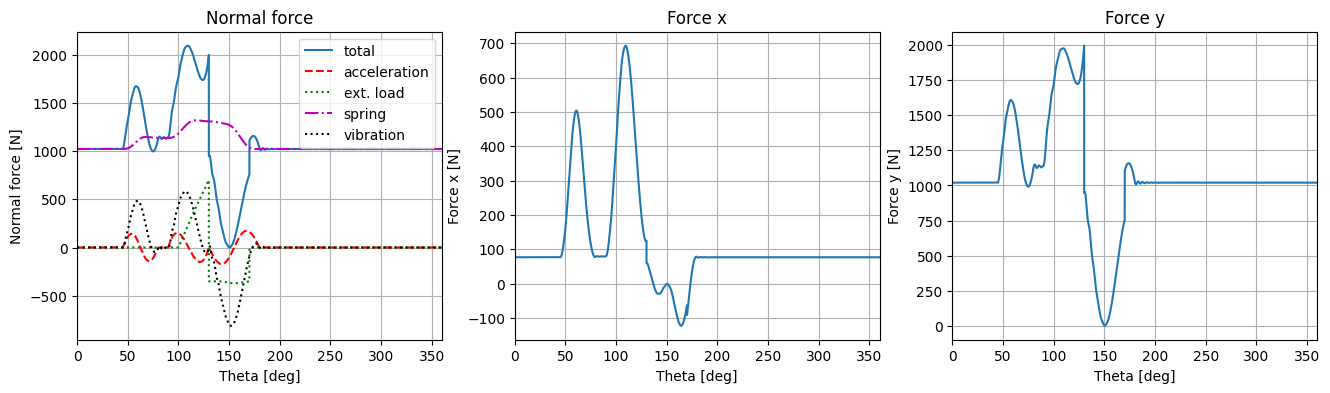

In [35]:
# Run multi-rise simulation for the full cam cycle
tau, lift_theta_multi, gamma_multi, t_out_multi = runMultiRiseSimulation(theta, lift, lam_multi, zeta, n_cycles=1)

# Calculate vibration force for the entire cycle
# h_max is the total lift (already used in runMultiRiseSimulation)
h_max = np.max(lift) - np.min(lift)
# Ensure h_max is positive
h_max = np.abs(h_max) * 1e-3  # convert to meters

# F_vib for the full cycle
F_vib = k_f * h_max * (lift_theta_multi - gamma_multi) / np.cos(pressure_angle_optimal_exc)

# Plot only the vibration force
plt.figure(figsize=(12, 4))
plt.plot(theta_deg, F_vib)
plt.xlabel('Theta [deg]')
plt.ylabel('Vibration force [N]')
plt.xlim([0, 360])
plt.grid()
plt.title('Vibration force (multi-rise)')
plt.show()

# Plot the forces with vibration
[normalforce_tot_with_vib, normalforce_acc, normalforce_load, normalforce_spring, force_x, force_y] = calculateForceWithVibration(
    rpm, lift, spring_constant, spring_preload, pressure_angle_optimal_exc, ext_load, mass, acc, F_vib
)
plotForces(theta_deg, normalforce_tot_with_vib, normalforce_acc, normalforce_load, normalforce_spring, force_x, force_y, normalforce_vib=F_vib)

# Calculate new k and preload
best_k, best_F0, best_max_force = grid_search_optimal_spring(
    rpm=rpm,
    lift=lift,
    pressure_angle=pressure_angle_optimal_exc,
    ext_load=ext_load,
    mass=mass,
    acc=acc,
    theta_deg=theta_deg,
    vib_force=F_vib
)

[normalforce_tot_with_vib, normalforce_acc, normalforce_load, normalforce_spring, force_x, force_y] = calculateForceWithVibration(
    rpm, lift, best_k, best_F0, pressure_angle_optimal_exc, ext_load, mass, acc, F_vib
)
plotForces(theta_deg, normalforce_tot_with_vib, normalforce_acc, normalforce_load, normalforce_spring, force_x, force_y, normalforce_vib=F_vib)

# Save design into file
This cell saves the variable that define the final design of the cam-follower system in a file called _cam.dat_.

In [36]:
# @title
import pickle
with open('cam.dat', 'wb') as f:
    pickle.dump((theta_deg,theta,dtheta,lift,vel_deg,vel,acc_deg,acc,pressure_angle_zero_exc,roc_pitch,roc_cam,base_radius,follower_radius,exc,ext_load,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y,mass,spring_constant,spring_preload,rpm), f)

# Upload design file and create all plots
This cell loads the final design of the cam-follower system contained in the file _cam.dat_ into the corresponding variables and generates all the relevant plots.

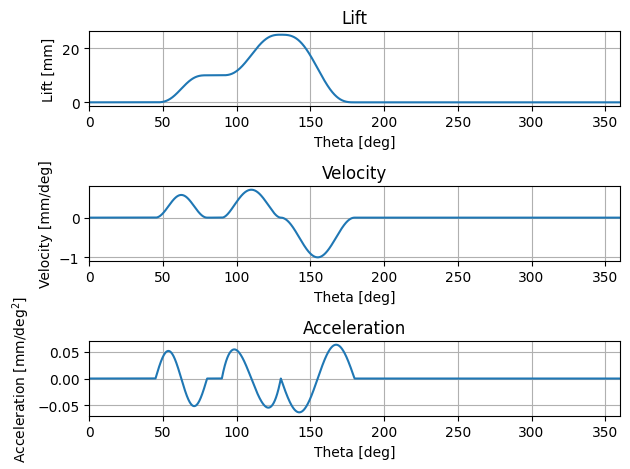

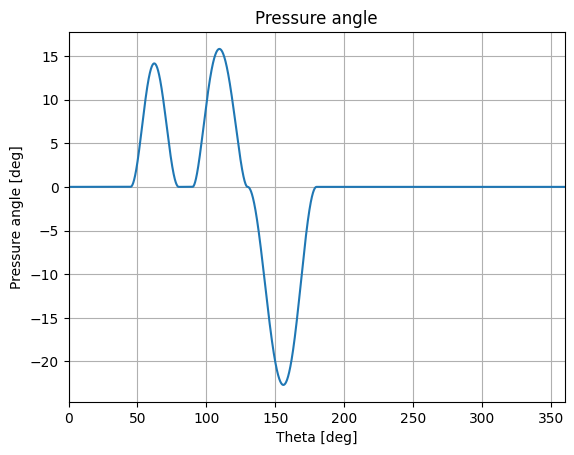

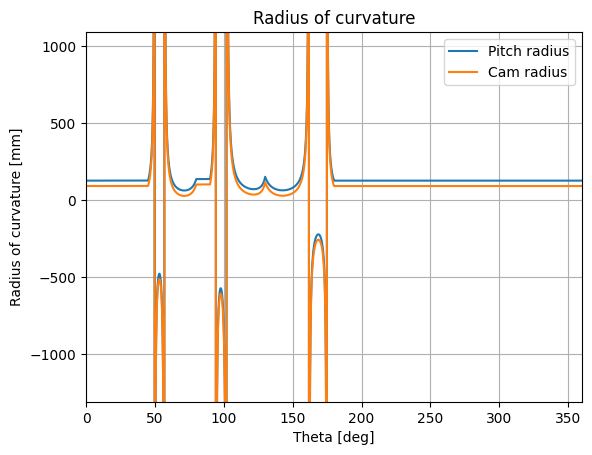

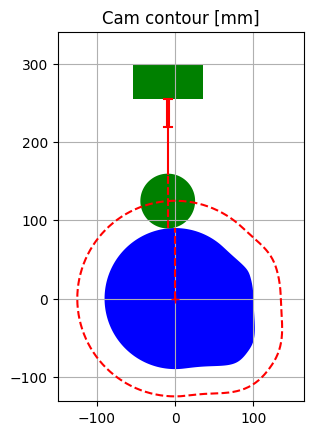

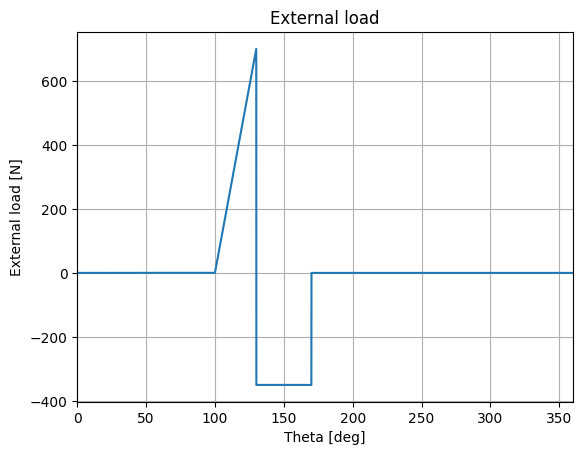

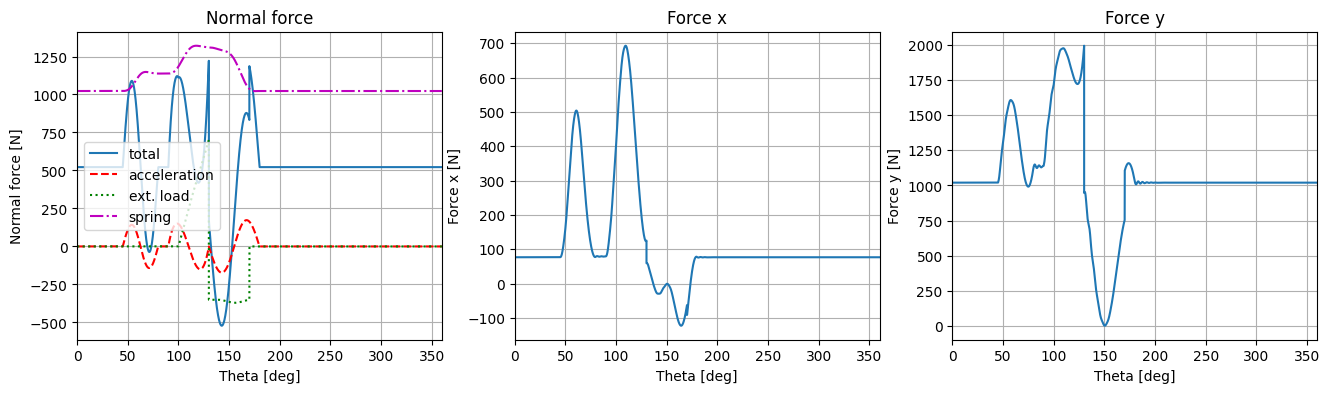

In [37]:
# @title
with open('cam.dat', 'rb') as f:
    theta_deg,theta,dtheta,lift,vel_deg,vel,acc_deg,acc,pressure_angle_zero_exc,roc_pitch,roc_cam,base_radius,follower_radius,exc,ext_load,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y,mass,spring_constant,spring_preload,rpm = pickle.load(f)

plotMotionLaw(theta_deg,lift,vel_deg,acc_deg)
plotPressureAngle(theta_deg,pressure_angle_zero_exc)
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam)
plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle_zero_exc,dtheta)
plotExternalLoad(theta_deg,ext_load)
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y)